# NYC Yellow Taxi — Data inspection, cleaning, aggregation, and splits

**Dataset:** `yellow_tripdata_2025-01.parquet` (TLC Yellow Taxi trips).

This notebook walks through a typical data-science workflow:

1. Inspect all features (types, ranges, missingness).
2. Investigate extreme values and plausible causes.
3. Clean data (missing values, outliers) with explicit rules.
4. Build a **normalized hourly time series** (citywide trip counts).
5. Define the modeling target: **hourly pickup count per taxi zone** `(pickup_hour, PULocationID) → pickup_count`, then **temporal 70/15/15 split** on clock hours and **feature selection** (correlation + mutual information) fit **only on train**.
6. Optional **trip-level** split for other tasks, plus **feature engineering** ideas.

> **Why chronological splits?** Demand and trips are time-ordered. Splitting by **ordered pickup hours** (for the zone-hour panel) or by trip time (for trip-level rows) avoids peeking at the future. Random splits inflate scores for forecasting.


In [1]:
# If packages are missing: pip install pandas pyarrow matplotlib seaborn scikit-learn
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

def resolve_parquet_path() -> Path:
    """Notebook may live in repo root or in data/; parquet may sit beside either."""
    here = Path.cwd().resolve()
    candidates = [
        here / "yellow_tripdata_2025-01.parquet",
        here / "data" / "yellow_tripdata_2025-01.parquet",
        here.parent / "yellow_tripdata_2025-01.parquet",
    ]
    for p in candidates:
        if p.is_file():
            return p
    raise FileNotFoundError(f"yellow_tripdata_2025-01.parquet not found. Tried: {candidates}")


DATA_PATH = resolve_parquet_path()
df = pd.read_parquet(DATA_PATH)
print(f"Loaded {len(df):,} rows × {df.shape[1]} columns")


Loaded 3,475,226 rows × 20 columns


## 1. Feature inventory

We record **name**, **dtype**, non-null count, and quick semantics. TLC dictionaries (vendor, payment type, rate code) are documented on the [TLC trip record data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page) page.


In [2]:
features = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "null_pct": (df.isna().mean() * 100).round(2),
})
features


,dtype,non_null,null_pct
VendorID,int32,3475226,0.00
tpep_pickup_datetime,datetime64[us],3475226,0.00
tpep_dropoff_datetime,datetime64[us],3475226,0.00
passenger_count,float64,2935077,15.54
trip_distance,float64,3475226,0.00
RatecodeID,float64,2935077,15.54
store_and_fwd_flag,str,2935077,15.54
PULocationID,int32,3475226,0.00
DOLocationID,int32,3475226,0.00
payment_type,int64,3475226,0.00


In [3]:
df.head(10)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0
5,2,2025-01-01 00:48:24,2025-01-01 01:08:26,2.0,2.63,1.0,N,239,68,2,19.1,1.0,0.5,0.00,0.0,1.0,24.10,2.5,0.0,0.0
6,1,2025-01-01 00:14:47,2025-01-01 00:16:15,0.0,0.40,1.0,N,170,170,1,4.4,3.5,0.5,2.35,0.0,1.0,11.75,2.5,0.0,0.0
7,1,2025-01-01 00:39:27,2025-01-01 00:51:51,0.0,1.60,1.0,N,234,148,1,12.1,3.5,0.5,2.00,0.0,1.0,19.10,2.5,0.0,0.0
8,1,2025-01-01 00:53:43,2025-01-01 01:13:23,0.0,2.80,1.0,N,148,170,1,19.1,3.5,0.5,3.00,0.0,1.0,27.10,2.5,0.0,0.0
9,2,2025-01-01 00:00:02,2025-01-01 00:09:36,1.0,1.71,1.0,N,237,262,2,11.4,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.0,0.0


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
VendorID,3475226.0,NaN,NaN,NaN,1.785428,1.0,2.0,2.0,2.0,7.0,0.426328
tpep_pickup_datetime,3475226,NaN,NaN,NaN,2025-01-17 11:02:55.910964,2024-12-31 20:47:55,2025-01-10 07:59:01,2025-01-17 15:41:33,2025-01-24 19:34:06,2025-02-01 00:00:44,NaN
tpep_dropoff_datetime,3475226,NaN,NaN,NaN,2025-01-17 11:17:56.997901,2024-12-18 07:52:40,2025-01-10 08:15:29.500000,2025-01-17 15:59:34,2025-01-24 19:48:31,2025-02-01 23:44:11,NaN
passenger_count,2935077.0,NaN,NaN,NaN,1.297859,0.0,1.0,1.0,1.0,9.0,0.75075
trip_distance,3475226.0,NaN,NaN,NaN,5.855126,0.0,0.98,1.67,3.1,276423.57,564.6016
RatecodeID,2935077.0,NaN,NaN,NaN,2.482535,1.0,1.0,1.0,1.0,99.0,11.632772
store_and_fwd_flag,2935077,2,N,2927431,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PULocationID,3475226.0,NaN,NaN,NaN,165.191576,1.0,132.0,162.0,234.0,265.0,64.529483
DOLocationID,3475226.0,NaN,NaN,NaN,164.125177,1.0,113.0,162.0,234.0,265.0,69.401686
payment_type,3475226.0,NaN,NaN,NaN,1.036623,0.0,1.0,1.0,1.0,5.0,0.701333


## 2. Missing values — pattern, not just counts

Many TLC files show a **block** of columns that are null together (same row index). We check whether nulls on `passenger_count` align with nulls on `RatecodeID`, `store_and_fwd_flag`, etc.


In [5]:
cols_sparse = ["passenger_count", "RatecodeID", "store_and_fwd_flag", "congestion_surcharge", "Airport_fee"]
present = [c for c in cols_sparse if c in df.columns]

m = df["passenger_count"].isna()
print(f"Rows with null passenger_count: {m.sum():,} ({100*m.mean():.2f}%)")

# Given passenger_count is null, do the other sparse columns tend to be null on the same rows?
other = [c for c in present if c != "passenger_count"]
if m.any() and other:
    joint = df.loc[m, other].isna().all(axis=1)
    print(f"Among those rows, share with ALL null in {other}: {joint.mean():.4f}")
    print("  (≈1.0 means those fields are jointly missing with passenger_count.)")

if "VendorID" in df.columns:
    print("\nVendorID distribution — all rows:")
    print(df["VendorID"].value_counts(normalize=True).round(4))
    print("\nVendorID among rows WITH missing sparse block:")
    print(df.loc[m, "VendorID"].value_counts(normalize=True).round(4))


Rows with null passenger_count: 540,149 (15.54%)
Among those rows, share with ALL null in ['RatecodeID', 'store_and_fwd_flag', 'congestion_surcharge', 'Airport_fee']: 1.0000
  (≈1.0 means those fields are jointly missing with passenger_count.)

VendorID distribution — all rows:
VendorID
2    0.7826
1    0.2169
7    0.0003
6    0.0001
Name: proportion, dtype: float64

VendorID among rows WITH missing sparse block:
VendorID
2    0.8358
1    0.1633
6    0.0009
Name: proportion, dtype: float64


**Interpretation (typical TLC behavior):** A subset of vendor/reporting pipelines omits passenger count, rate code, store-and-forward flag, and some surcharges. Imputation should respect this structure (e.g. fill `passenger_count` with median *within vendor* or use an explicit “unknown” category) rather than assuming MCAR (missing completely at random).


## 3. Derived fields for sanity checks

- **Trip duration** from pickup/dropoff (watch negatives / absurd values).
- **Implied speed** = distance / duration (NYC street trips rarely sustain very high speeds for whole trips — useful for spotting bad rows).


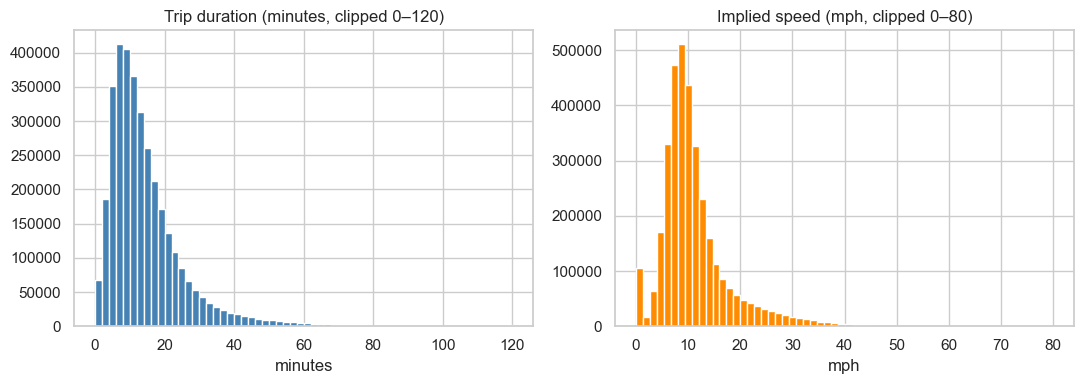

Duration <= 0: 2051
Trip distance < 0: 0


In [6]:
df = df.copy()
df["duration_min"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60.0
# Avoid divide-by-zero
df["implied_mph"] = np.where(
    df["duration_min"] > (1 / 60),  # > 1 second
    df["trip_distance"] / (df["duration_min"] / 60.0),
    np.nan,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["duration_min"].clip(0, 120), bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Trip duration (minutes, clipped 0–120)")
axes[0].set_xlabel("minutes")
axes[1].hist(df["implied_mph"].replace([np.inf, -np.inf], np.nan).dropna().clip(0, 80), bins=60, color="darkorange", edgecolor="white")
axes[1].set_title("Implied speed (mph, clipped 0–80)")
axes[1].set_xlabel("mph")
plt.tight_layout()
plt.show()

print("Duration <= 0:", (df["duration_min"] <= 0).sum())
print("Trip distance < 0:", (df["trip_distance"] < 0).sum())


## 4. Extreme values — where and why?

We rank heavy tails for **distance**, **fare**, and **total_amount**, then slice by **VendorID** and **payment_type** to see if outliers cluster (data entry, refunds, or long-distance trips).


In [7]:
try:
    from IPython.display import display
except ImportError:
    display = print


def top_outliers(frame, col, n=8):
    return frame.nlargest(n, col)[
        ["tpep_pickup_datetime", "tpep_dropoff_datetime", "VendorID", "trip_distance",
         "fare_amount", "total_amount", "duration_min", "payment_type", "PULocationID", "DOLocationID"]
    ]

for col in ["trip_distance", "fare_amount", "total_amount"]:
    print(f"\n=== Top {col} ===")
    display(top_outliers(df, col))

# Quantiles for context
qcols = ["trip_distance", "fare_amount", "total_amount", "duration_min", "tip_amount"]
print("\nQuantiles (1%, 50%, 99%, 99.9%):")
print(df[qcols].quantile([0.01, 0.5, 0.99, 0.999]).T)



=== Top trip_distance ===


,tpep_pickup_datetime,tpep_dropoff_datetime,VendorID,trip_distance,fare_amount,total_amount,duration_min,payment_type,PULocationID,DOLocationID
3275762,2025-01-22 21:04:00,2025-01-22 21:13:00,2,276423.57,-4.75,5.00,9.0,0,161,170
3188501,2025-01-19 14:51:00,2025-01-19 14:58:00,2,276099.95,9.13,13.88,7.0,0,224,233
3240337,2025-01-21 09:19:00,2025-01-21 09:45:00,2,222167.49,31.19,35.94,26.0,0,52,144
3112173,2025-01-16 10:47:00,2025-01-16 11:11:00,2,206137.99,24.89,29.64,24.0,0,263,48
3374854,2025-01-26 17:46:00,2025-01-26 17:59:00,2,202771.63,10.10,14.85,13.0,0,50,186
3081597,2025-01-14 19:18:00,2025-01-14 19:36:00,2,189687.43,12.70,17.45,18.0,0,246,164
3069039,2025-01-13 21:11:00,2025-01-13 21:17:00,2,181139.99,6.33,11.08,6.0,0,100,90
3312563,2025-01-24 08:33:00,2025-01-24 08:44:00,2,168079.57,-4.00,4.49,11.0,0,42,238



=== Top fare_amount ===


,tpep_pickup_datetime,tpep_dropoff_datetime,VendorID,trip_distance,fare_amount,total_amount,duration_min,payment_type,PULocationID,DOLocationID
1780915,2025-01-20 12:07:18,2025-01-20 12:12:42,1,1.60,863372.12,863380.37,5.400000,4,138,8
1404958,2025-01-16 12:23:14,2025-01-17 14:41:56,2,255.33,2450.90,2506.71,1578.700000,2,161,265
1832645,2025-01-21 05:17:57,2025-01-21 08:19:45,2,188.88,1309.20,1311.70,181.800000,2,247,265
2358832,2025-01-26 00:04:04,2025-01-26 00:04:42,2,0.00,950.00,953.50,0.633333,2,142,142
2358836,2025-01-26 00:22:47,2025-01-26 00:22:55,2,0.00,950.00,951.00,0.133333,2,226,226
2358837,2025-01-26 00:24:25,2025-01-26 00:24:35,2,0.00,950.00,951.00,0.166667,2,226,226
1346041,2025-01-15 19:14:42,2025-01-15 21:46:13,2,143.54,936.80,969.05,151.516667,1,132,265
562143,2025-01-07 19:12:25,2025-01-07 19:14:04,2,0.10,900.00,901.00,1.650000,3,226,226



=== Top total_amount ===


,tpep_pickup_datetime,tpep_dropoff_datetime,VendorID,trip_distance,fare_amount,total_amount,duration_min,payment_type,PULocationID,DOLocationID
1780915,2025-01-20 12:07:18,2025-01-20 12:12:42,1,1.60,863372.12,863380.37,5.400000,4,138,8
1404958,2025-01-16 12:23:14,2025-01-17 14:41:56,2,255.33,2450.90,2506.71,1578.700000,2,161,265
1832645,2025-01-21 05:17:57,2025-01-21 08:19:45,2,188.88,1309.20,1311.70,181.800000,2,247,265
1346041,2025-01-15 19:14:42,2025-01-15 21:46:13,2,143.54,936.80,969.05,151.516667,1,132,265
2358832,2025-01-26 00:04:04,2025-01-26 00:04:42,2,0.00,950.00,953.50,0.633333,2,142,142
2358836,2025-01-26 00:22:47,2025-01-26 00:22:55,2,0.00,950.00,951.00,0.133333,2,226,226
2358837,2025-01-26 00:24:25,2025-01-26 00:24:35,2,0.00,950.00,951.00,0.166667,2,226,226
2358828,2025-01-26 00:00:56,2025-01-26 00:01:06,2,0.00,900.00,903.50,0.166667,2,142,142



Quantiles (1%, 50%, 99%, 99.9%):
                   0.010  0.500       0.990       0.999
trip_distance   0.000000   1.67   19.500000   28.857750
fare_amount   -10.700000  12.11   72.300000  132.000000
total_amount  -15.700000  19.95  102.920000  163.980000
duration_min    0.666667  11.70   58.916667   98.262917
tip_amount      0.000000   2.45   17.190000   27.187750


In [8]:
# Payment type for very large totals (TLC: 1=CC, 2=cash, 3=no charge, 4=dispute, 5=unknown, 0=void/grouped)
hi = df["total_amount"] > df["total_amount"].quantile(0.999)
print("payment_type among top 0.1% total_amount:")
print(df.loc[hi, "payment_type"].value_counts())

print("\nVendorID among rows with total_amount < 0 (possible adjustments/refunds):")
print(df.loc[df["total_amount"] < 0, "VendorID"].value_counts().head())


payment_type among top 0.1% total_amount:
payment_type
1    2790
2     501
4     134
3      34
0      16
Name: count, dtype: int64

VendorID among rows with total_amount < 0 (possible adjustments/refunds):
VendorID
2    63037
Name: count, dtype: int64


**Why extremes appear**

| Pattern | Plausible cause |
|--------|------------------|
| Huge `trip_distance` with short duration | GPS/meter error, test rows, or bad sync |
| Very large `fare_amount` / `total_amount` | Rare long trips, split rides, or recording errors |
| Negative totals | Refunds, disputes, or corrections in the feed |
| Null block on several columns | Vendor-specific reporting gaps |

We encode cleaning as **explicit boolean masks** so you can audit how many rows were removed or imputed.


## 5. Cleaning — rules, transparency, and a cleaned trip table

**Missing values**

- `passenger_count`: impute with **median by VendorID** (fallback: global median); optional alternative is **−1 or "unknown"** for tree models.
- `RatecodeID`, `store_and_fwd_flag`, `congestion_surcharge`, `Airport_fee`: impute with **mode within VendorID** or **0 / 'N'** where domain-appropriate (documented in code).

**Outliers (domain + quantile caps)**

- Drop or flag rows with **non-positive duration** or **negative distance**.
- Flag **implausible speed** (e.g. > 80 mph for entire trip) as suspicious meter data.
- **Winsorize or cap** `trip_distance` and `fare_amount` at high quantiles (e.g. 99.5th) *or* drop above thresholds — here we **drop** egregious rows (distance > 100 mi, fare > 500, total > 500) as a simple baseline; tune for your use case.

You can relax or tighten thresholds in `RULES` below.


In [9]:
RULES = {
    "max_trip_distance_mi": 100.0,
    "max_fare_amount": 500.0,
    "max_total_amount": 500.0,
    "max_implied_mph": 80.0,
    "min_duration_min": 1 / 60,  # at least 1 second
}

df_clean = df.copy()

# Masks
neg_duration = df_clean["duration_min"] <= 0
neg_dist = df_clean["trip_distance"] < 0
extreme_dist = df_clean["trip_distance"] > RULES["max_trip_distance_mi"]
extreme_fare = df_clean["fare_amount"] > RULES["max_fare_amount"]
extreme_total = df_clean["total_amount"] > RULES["max_total_amount"]
bad_speed = df_clean["implied_mph"].notna() & (df_clean["implied_mph"] > RULES["max_implied_mph"])

print("Rows flagged:")
print("  non-positive duration:", neg_duration.sum())
print("  negative distance:", neg_dist.sum())
print("  distance > max:", extreme_dist.sum())
print("  fare > max:", extreme_fare.sum())
print("  total > max:", extreme_total.sum())
print("  implied mph > max:", bad_speed.sum())

invalid = neg_duration | neg_dist | extreme_dist | extreme_fare | extreme_total | bad_speed
df_clean = df_clean.loc[~invalid].copy()
print(f"\nRemoved {invalid.sum():,} rows; remaining {len(df_clean):,}")

# Imputations
med_pc = df_clean.groupby("VendorID")["passenger_count"].transform("median")
df_clean["passenger_count"] = df_clean["passenger_count"].fillna(med_pc).fillna(df_clean["passenger_count"].median())

for col, fill in [
    ("RatecodeID", lambda g: g.median()),
    ("congestion_surcharge", 0.0),
    ("Airport_fee", 0.0),
]:
    if col in df_clean.columns:
        if callable(fill):
            df_clean[col] = df_clean[col].fillna(df_clean.groupby("VendorID")[col].transform("median"))
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        else:
            df_clean[col] = df_clean[col].fillna(fill)

if "store_and_fwd_flag" in df_clean.columns:
    df_clean["store_and_fwd_flag"] = df_clean["store_and_fwd_flag"].fillna("N")

print("\nRemaining null % (sample):")
print((df_clean.isna().mean() * 100).round(3).sort_values(ascending=False).head(15))


Rows flagged:
  non-positive duration: 2051
  negative distance: 0
  distance > max: 162
  fare > max: 55
  total > max: 79
  implied mph > max: 967

Removed 3,122 rows; remaining 3,472,104

Remaining null % (sample):
implied_mph              0.003
tpep_pickup_datetime     0.000
duration_min             0.000
cbd_congestion_fee       0.000
Airport_fee              0.000
congestion_surcharge     0.000
total_amount             0.000
improvement_surcharge    0.000
tolls_amount             0.000
tip_amount               0.000
mta_tax                  0.000
VendorID                 0.000
fare_amount              0.000
payment_type             0.000
DOLocationID             0.000
dtype: float64


## 6. Normalized hourly aggregation

**Rationale:** Raw trips are irregular events. For demand forecasting, dashboards, or as features for other models, aggregating to **UTC-naive hourly buckets on pickup time** gives a regular lattice. TLC timestamps are often stored without explicit timezone; treat as **naive local** for exploration, or join a timezone library if you need strict ET.

We aggregate **cleaned** trips:

- `trip_count` — number of trips starting in that hour  
- `mean_distance`, `mean_total`, `sum_total` — simple summaries  
- Optional: break out by `PULocationID` (keeps table wider; shown as citywide only here for a compact series)

The **zone × hour demand panel** and `pickup_count` target are built in **§6b** (`dt.floor('h')` + `groupby`).


In [10]:
# Hourly bucket (pandas 'h' = hourly)
g = pd.Grouper(key="tpep_pickup_datetime", freq="h")
hourly = (
    df_clean.groupby(g)
    .agg(
        trip_count=("VendorID", "size"),
        mean_trip_distance=("trip_distance", "mean"),
        mean_total_amount=("total_amount", "mean"),
        sum_total_amount=("total_amount", "sum"),
        mean_duration_min=("duration_min", "mean"),
    )
    .reset_index()
    .sort_values("tpep_pickup_datetime")
)
hourly.head(12)


,tpep_pickup_datetime,trip_count,mean_trip_distance,mean_total_amount,sum_total_amount,mean_duration_min
0,2024-12-31 20:00:00,3,2.720000,29.766667,89.30,19.427778
1,2024-12-31 21:00:00,3,2.320000,19.100000,57.30,10.350000
2,2024-12-31 22:00:00,0,NaN,NaN,0.00,NaN
3,2024-12-31 23:00:00,14,3.485714,26.662143,373.27,18.208333
4,2025-01-01 00:00:00,7339,3.288374,24.267928,178102.32,16.855294
5,2025-01-01 01:00:00,8460,3.263435,23.869396,201935.09,16.598739
6,2025-01-01 02:00:00,7249,3.406768,22.088884,160122.32,16.031163
7,2025-01-01 03:00:00,4912,3.436851,18.649149,91604.62,14.200682
8,2025-01-01 04:00:00,2913,3.831129,21.035870,61277.49,14.536131
9,2025-01-01 05:00:00,1428,4.715672,22.909300,32714.48,13.820903


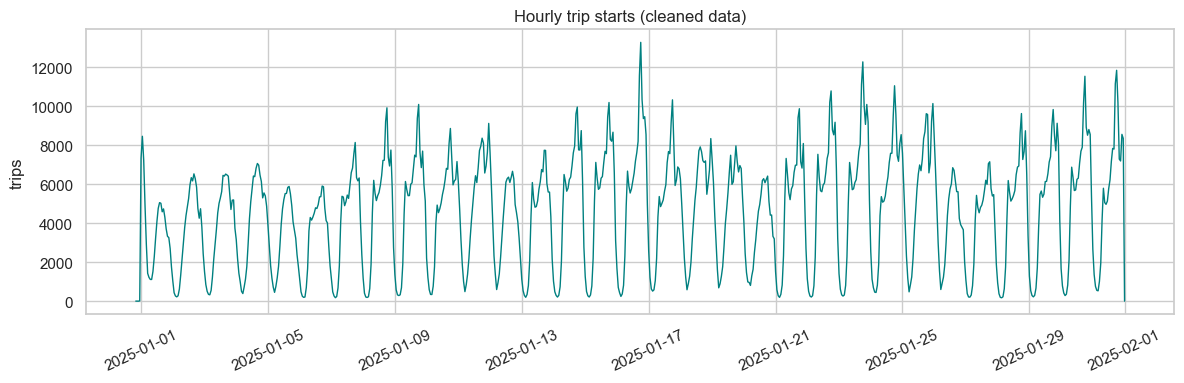

In [11]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hourly["tpep_pickup_datetime"], hourly["trip_count"], color="teal", linewidth=1)
ax.set_title("Hourly trip starts (cleaned data)")
ax.set_ylabel("trips")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


### 6b. Modeling target: hourly pickups per taxi zone

Each row is one **(pickup hour, pickup zone)** pair. The target is how many cleaned trips **started** in that zone in that hour:

```python
pickup_hour = floor(tpep_pickup_datetime to hour)
pickup_count = count of trips per (pickup_hour, PULocationID)
```

We build this from **`df_clean`** so garbage trips removed earlier do not inflate demand. To match **raw** TLC counts exactly, run the same `groupby` on `df` *before* the cleaning cell (not recommended for modeling until you trust the raw rows).

**Split:** We sort **distinct** `pickup_hour` values, assign the first 70% of hours to train, next 15% to validation, last 15% to test. Every zone row in an hour inherits that hour’s split—so the model never trains on future hours.


In [12]:
# Zone × hour panel (target)
trips = df_clean.copy()
trips["pickup_hour"] = trips["tpep_pickup_datetime"].dt.floor("h")

demand_panel = (
    trips.groupby(["pickup_hour", "PULocationID"], observed=True)
    .size()
    .reset_index(name="pickup_count")
)

print(demand_panel.shape)
demand_panel.head(10)


(96911, 3)


,pickup_hour,PULocationID,pickup_count
0,2024-12-31 20:00:00,48,1
1,2024-12-31 20:00:00,246,1
2,2024-12-31 20:00:00,249,1
3,2024-12-31 21:00:00,42,1
4,2024-12-31 21:00:00,141,1
5,2024-12-31 21:00:00,179,1
6,2024-12-31 23:00:00,43,1
7,2024-12-31 23:00:00,56,1
8,2024-12-31 23:00:00,68,1
9,2024-12-31 23:00:00,114,2


### 6b.1 Dense zone × hour grid (include zero-demand hours)

The earlier `demand_panel` only includes zone-hour pairs **with at least one pickup**. For forecasting, that bias hides true zeros and inflates performance. We therefore reindex to a **full zone × hour grid**, filling missing cells with `0` pickups before any splits or lags.


In [13]:
# Build a dense zone × hour panel (zeros included)
trips = df_clean.copy()
trips["pickup_hour"] = trips["tpep_pickup_datetime"].dt.floor("h")

h_min, h_max = trips["pickup_hour"].min(), trips["pickup_hour"].max()
hours = pd.date_range(h_min, h_max, freq="h")
zones = np.sort(trips["PULocationID"].unique())

idx = pd.MultiIndex.from_product([hours, zones], names=["pickup_hour", "PULocationID"])
counts = trips.groupby(["pickup_hour", "PULocationID"], observed=True).size()

# Reindex to the full grid; missing = 0 pickups

demand_panel = (
    counts.reindex(idx, fill_value=0)
    .reset_index(name="pickup_count")
    .sort_values(["pickup_hour", "PULocationID"])
)

print(demand_panel.shape)
demand_panel.head(10)


(195489, 3)


,pickup_hour,PULocationID,pickup_count
0,2024-12-31 20:00:00,1,0
1,2024-12-31 20:00:00,2,0
2,2024-12-31 20:00:00,3,0
3,2024-12-31 20:00:00,4,0
4,2024-12-31 20:00:00,5,0
5,2024-12-31 20:00:00,6,0
6,2024-12-31 20:00:00,7,0
7,2024-12-31 20:00:00,8,0
8,2024-12-31 20:00:00,9,0
9,2024-12-31 20:00:00,10,0


In [14]:
# Calendar / cyclical features from pickup_hour (known at prediction time)
# PULocationID kept as numeric for screening; treat as categorical in real models.


def add_demand_features(panel: pd.DataFrame) -> pd.DataFrame:
    out = panel.copy()
    ts = out["pickup_hour"]
    out["hour"] = ts.dt.hour.astype(np.int32)
    out["dow"] = ts.dt.dayofweek.astype(np.int32)
    out["month"] = ts.dt.month.astype(np.int32)
    out["day"] = ts.dt.day.astype(np.int32)
    out["is_weekend"] = (out["dow"] >= 5).astype(np.int32)
    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24.0)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24.0)
    out["dow_sin"] = np.sin(2 * np.pi * out["dow"] / 7.0)
    out["dow_cos"] = np.cos(2 * np.pi * out["dow"] / 7.0)
    return out


panel_model = add_demand_features(demand_panel)

unique_hours = np.sort(panel_model["pickup_hour"].unique())
n_h = len(unique_hours)
h1, h2 = int(n_h * 0.70), int(n_h * 0.85)
train_hours = set(unique_hours[:h1])
val_hours = set(unique_hours[h1:h2])
test_hours = set(unique_hours[h2:])

ph = panel_model["pickup_hour"]
panel_model["split"] = np.where(
    ph.isin(train_hours),
    "train",
    np.where(ph.isin(val_hours), "val", "test"),
)

print(f"Distinct hours: {n_h} | train {len(train_hours)} | val {len(val_hours)} | test {len(test_hours)}")
print(panel_model["split"].value_counts())
panel_model.head()


Distinct hours: 749 | train 524 | val 112 | test 113
split
train    136764
test      29493
val       29232
Name: count, dtype: int64


,pickup_hour,PULocationID,pickup_count,hour,dow,month,day,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,split
0,2024-12-31 20:00:00,1,0,20,1,12,31,0,-0.866025,0.5,0.781831,0.62349,train
1,2024-12-31 20:00:00,2,0,20,1,12,31,0,-0.866025,0.5,0.781831,0.62349,train
2,2024-12-31 20:00:00,3,0,20,1,12,31,0,-0.866025,0.5,0.781831,0.62349,train
3,2024-12-31 20:00:00,4,0,20,1,12,31,0,-0.866025,0.5,0.781831,0.62349,train
4,2024-12-31 20:00:00,5,0,20,1,12,31,0,-0.866025,0.5,0.781831,0.62349,train


### 6b (continued). Causal lags and a few engineered columns

**Lags:** Counts only exist for zone-hours with trips, so we **reindex** to a full `(PULocationID × hourly timestamp)` grid, treat missing cells as **0 pickups**, then `groupby(zone).shift(k)` for **k = 1, 24, 168** hours. That is the same zone at the previous clock hour, same hour yesterday, and same hour last week. Leading NaNs are filled with **0**.

**Test / exploratory features:**

1. **`is_late_night`** — hour in `{22,…,5}`.
2. **`hour_x_weekend`** — `hour × is_weekend`.
3. **`zone_avg_pickup_train`** — mean `pickup_count` for that zone on **train** panel rows only (mapped to all splits; val/test labels are not used in the mean).
4. **`log1p_lag1h`** — `log1p` of the 1h lag to reduce skew.


In [15]:
def add_zone_hour_lags(panel: pd.DataFrame, count_col: str = "pickup_count") -> pd.DataFrame:
    """Causal lags per zone on a dense hour grid (gaps = zero demand)."""
    out = panel.copy()
    h_min, h_max = out["pickup_hour"].min(), out["pickup_hour"].max()
    hours = pd.date_range(h_min, h_max, freq="h")
    zones = np.sort(out["PULocationID"].unique())
    idx = pd.MultiIndex.from_product([zones, hours], names=["PULocationID", "pickup_hour"])
    base = (
        out[["PULocationID", "pickup_hour", count_col]]
        .drop_duplicates(subset=["PULocationID", "pickup_hour"])
        .set_index(["PULocationID", "pickup_hour"])
    )
    dense = base.reindex(idx, fill_value=0)
    g = dense.groupby(level=0, sort=False)[count_col]
    dense = dense.assign(
        pickup_count_lag1h=g.shift(1),
        pickup_count_lag24h=g.shift(24),
        pickup_count_lag168h=g.shift(168),
    )
    lag_cols = ["pickup_count_lag1h", "pickup_count_lag24h", "pickup_count_lag168h"]
    lag_df = dense.reset_index()[["PULocationID", "pickup_hour"] + lag_cols]
    merged = out.merge(lag_df, on=["PULocationID", "pickup_hour"], how="left", validate="one_to_one")
    merged[lag_cols] = merged[lag_cols].fillna(0.0)
    return merged


panel_model = add_zone_hour_lags(panel_model)

# --- Exploratory / test features ---
late_hours = {22, 23, 0, 1, 2, 3, 4, 5}
panel_model["is_late_night"] = panel_model["hour"].isin(late_hours).astype(np.int32)
panel_model["hour_x_weekend"] = (
    panel_model["hour"].astype(np.float64) * panel_model["is_weekend"].astype(np.float64)
)

train_mask_fs = panel_model["split"] == "train"
zone_avg_train = (
    panel_model.loc[train_mask_fs].groupby("PULocationID", observed=True)["pickup_count"].mean()
)
panel_model["zone_avg_pickup_train"] = panel_model["PULocationID"].map(zone_avg_train).fillna(0.0).astype(np.float64)
panel_model["log1p_lag1h"] = np.log1p(panel_model["pickup_count_lag1h"].clip(lower=0.0))

print(
    panel_model[
        [
            "pickup_hour",
            "PULocationID",
            "pickup_count",
            "pickup_count_lag1h",
            "pickup_count_lag24h",
            "pickup_count_lag168h",
            "is_late_night",
            "hour_x_weekend",
            "zone_avg_pickup_train",
            "log1p_lag1h",
        ]
    ].head(8)
)


          pickup_hour  PULocationID  pickup_count  pickup_count_lag1h  pickup_count_lag24h  pickup_count_lag168h  \
0 2024-12-31 20:00:00             1             0                 0.0                  0.0                   0.0   
1 2024-12-31 20:00:00             2             0                 0.0                  0.0                   0.0   
2 2024-12-31 20:00:00             3             0                 0.0                  0.0                   0.0   
3 2024-12-31 20:00:00             4             0                 0.0                  0.0                   0.0   
4 2024-12-31 20:00:00             5             0                 0.0                  0.0                   0.0   
5 2024-12-31 20:00:00             6             0                 0.0                  0.0                   0.0   
6 2024-12-31 20:00:00             7             0                 0.0                  0.0                   0.0   
7 2024-12-31 20:00:00             8             0                 0.0   

### 6b.2 Holiday feature (NYC observed holidays)

We add a simple binary holiday flag. This is intentionally **minimal** (no API calls) and can be replaced later with a full NYC holiday calendar or a richer event dataset.


In [16]:
# Minimal NYC holidays in this file's date range (expand as needed)
NYC_HOLIDAYS = pd.to_datetime([
    "2025-01-01",  # New Year's Day
    "2025-01-20",  # MLK Day
]).normalize()

panel_model["pickup_date"] = panel_model["pickup_hour"].dt.normalize()
panel_model["is_holiday"] = panel_model["pickup_date"].isin(NYC_HOLIDAYS).astype(np.int32)


### 6b.3 Cold-start handling for weekly lags

Weekly lags (`168h`) are undefined for the first week. We drop those early hours so that lag-based baselines and models do not get artificial zeros.


In [17]:
min_hour = panel_model["pickup_hour"].min()
cutoff = min_hour + pd.Timedelta(hours=168)

panel_model = panel_model.loc[panel_model["pickup_hour"] >= cutoff].copy()
print("Rows after cold-start drop:", len(panel_model))


Rows after cold-start drop: 151641


### 6c. Feature selection vs. `pickup_count` (train only)

Predictors include **calendar / cyclical** fields, **causal lags** (1h / 24h / 168h, same zone), and **engineered** columns from §6b (continued). `zone_avg_pickup_train` uses **train** panel rows only per zone.

- **Pearson / Spearman** — linear / monotonic association on **train** rows.
- **Mutual information** — non-linear univariate strength.

Do **not** rank features using val/test rows.


In [18]:
from sklearn.feature_selection import mutual_info_regression

FEATURE_COLS = [
    "PULocationID",
    "hour",
    "dow",
    "month",
    "day",
    "is_weekend",
    "is_holiday",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "pickup_count_lag1h",
    "pickup_count_lag24h",
    "pickup_count_lag168h",
    "log1p_lag1h",
    "is_late_night",
    "hour_x_weekend",
    "zone_avg_pickup_train",
]

train_only = panel_model["split"] == "train"
X_tr = panel_model.loc[train_only, FEATURE_COLS]
y_tr = panel_model.loc[train_only, "pickup_count"]

pearson = X_tr.corrwith(y_tr)
spear = X_tr.assign(pickup_count=y_tr).corr(numeric_only=True, method="spearman")["pickup_count"].drop(
    "pickup_count", errors="ignore"
)

mi = mutual_info_regression(X_tr, y_tr, random_state=0)
mi_s = pd.Series(mi, index=FEATURE_COLS, name="mutual_info")

selection = (
    pd.DataFrame({"pearson": pearson, "spearman": spear, "mutual_info": mi_s})
    .assign(abs_pearson=lambda d: d["pearson"].abs())
    .sort_values("mutual_info", ascending=False)
)
selection.round(4)


/Users/firasastwani/Desktop/Data Mining/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/firasastwani/Desktop/Data Mining/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,pearson,spearman,mutual_info,abs_pearson
pickup_count_lag1h,0.9506,0.7848,0.7273,0.9506
log1p_lag1h,0.7506,0.7848,0.7238,0.7506
pickup_count_lag24h,0.9146,0.7755,0.6894,0.9146
pickup_count_lag168h,0.9208,0.7608,0.6790,0.9208
zone_avg_pickup_train,0.7548,0.7796,0.6321,0.7548
PULocationID,0.1343,0.1058,0.5586,0.1343
hour,0.1328,0.0949,0.0490,0.1328
hour_sin,-0.1393,-0.0287,0.0188,0.1393
hour_cos,-0.0707,-0.1257,0.0181,0.0707
is_late_night,-0.1153,-0.1543,0.0141,0.1153


## 7. Baseline forecasts (seasonal naive + pooled XGBoost)

We compare fast **seasonal naive** baselines against a pooled **XGBoost** model that leverages engineered lag + time features and treats `PULocationID` as categorical.


### What is being predicted? (unit of every row)

After aggregation, **each row** of `model_df` is **one taxi zone × one clock hour**:

- **`pickup_hour`** — the hour when trips **start** (floored to the hour)
- **`PULocationID`** — **pickup** TLC zone (where the passenger was picked up)
- **`pickup_count`** — **how many cleaned trips started in that zone during that hour** (the target \(y\))

So the model is **not** predicting a single city-wide total per hour unless you sum zones yourself. It is predicting **zone-specific hourly demand**. A **pooled** model (XGBoost here) still does that: it outputs one number per row, using **zone id + lags + calendar features** for that row.

### How do MAE / RMSE arise?

Take the **test** split (future hours, never seen in training). For every test row \(i\):

- **error** \(e_i = y_i - \hat{y}_i\) in **trips** (same units as `pickup_count`)
- **MAE** \(= \frac{1}{N}\sum_i |e_i|\) — average absolute miss, in **trips per zone-hour**
- **RMSE** \(= \sqrt{\frac{1}{N}\sum_i e_i^2}\) — penalizes occasional **large** misses more than MAE

So if MAE ≈ 4, a plain-language gloss is: “on a typical test zone-hour, the forecast is off by about 4 trips,” **not** “4%” and **not** “4 thousand.”

### Micro-MAE vs macro-MAE by zone

- **Micro-MAE** (what `mean_absolute_error` does on all test rows): busy zones contribute **more rows** and usually matter more for total city throughput.
- **Macro-MAE** (simple average of each zone’s MAE): every zone counts **equally** — useful to see **which zones are intrinsically harder**, even if they are small.

Section **8.5** plots **per-zone** MAE (each zone’s average |error| over its test hours) — that answers “how hard is this zone to predict?”


In [19]:
from time import time
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Metrics helper (MAPE uses max(y,1) to avoid division by zero)
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    denom = np.maximum(y_true, 1.0)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100.0
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

# Work on a clean modeling frame
model_df = panel_model.copy()

# Seasonal naive baselines (zone-aware via lags)
model_df["pred_lag1h"] = model_df["pickup_count_lag1h"]
model_df["pred_lag24h"] = model_df["pickup_count_lag24h"]
model_df["pred_lag168h"] = model_df["pickup_count_lag168h"]
model_df["pred_blend"] = (
    0.6 * model_df["pred_lag1h"]
    + 0.3 * model_df["pred_lag24h"]
    + 0.1 * model_df["pred_lag168h"]
)

for split in ["val", "test"]:
    sub = model_df.loc[model_df["split"] == split]
    print(f"\n=== Seasonal naive baselines ({split}) ===")
    for col in ["pred_lag1h", "pred_lag24h", "pred_lag168h", "pred_blend"]:
        m = regression_metrics(sub["pickup_count"], sub[col])
        print(col, {k: round(v, 4) for k, v in m.items()})



=== Seasonal naive baselines (val) ===
pred_lag1h {'MAE': 6.04, 'RMSE': np.float64(19.9186), 'MAPE': np.float64(54.4823)}
pred_lag24h {'MAE': 7.2738, 'RMSE': np.float64(29.4747), 'MAPE': np.float64(75.5443)}
pred_lag168h {'MAE': 4.9572, 'RMSE': np.float64(16.2394), 'MAPE': np.float64(63.3873)}
pred_blend {'MAE': 4.9193, 'RMSE': np.float64(16.2012), 'MAPE': np.float64(55.2231)}

=== Seasonal naive baselines (test) ===
pred_lag1h {'MAE': 5.9821, 'RMSE': np.float64(20.4551), 'MAPE': np.float64(81.0725)}
pred_lag24h {'MAE': 5.1083, 'RMSE': np.float64(17.8801), 'MAPE': np.float64(55.6757)}
pred_lag168h {'MAE': 4.4856, 'RMSE': np.float64(16.5405), 'MAPE': np.float64(77.5724)}
pred_blend {'MAE': 4.4306, 'RMSE': np.float64(15.0117), 'MAPE': np.float64(67.2302)}


In [20]:
# If needed: pip install xgboost
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

CAT_COLS = ["PULocationID"]
NUM_COLS = [
    "hour",
    "dow",
    "month",
    "day",
    "is_weekend",
    "is_holiday",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "pickup_count_lag1h",
    "pickup_count_lag24h",
    "pickup_count_lag168h",
    "log1p_lag1h",
    "is_late_night",
    "hour_x_weekend",
    "zone_avg_pickup_train",
]

X = model_df[CAT_COLS + NUM_COLS]
y = model_df["pickup_count"]

train_mask = model_df["split"] == "train"
val_mask = model_df["split"] == "val"
test_mask = model_df["split"] == "test"

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
        ("num", "passthrough", NUM_COLS),
    ],
    remainder="drop",
    sparse_threshold=0.3,
)

xgb = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=-1,
    random_state=0,
)

pipe = Pipeline([
    ("prep", preprocess),
    ("model", xgb),
])

start = time()
pipe.fit(X[train_mask], y[train_mask])
train_time = time() - start

for split, mask in [("val", val_mask), ("test", test_mask)]:
    preds = pipe.predict(X[mask])
    m = regression_metrics(y[mask], preds)
    print(f"\n=== XGBoost pooled ({split}) ===")
    print({k: round(v, 4) for k, v in m.items()})

print(f"Training time (s): {train_time:.2f}")



=== XGBoost pooled (val) ===
{'MAE': 3.8426, 'RMSE': np.float64(12.1296), 'MAPE': np.float64(53.3401)}

=== XGBoost pooled (test) ===
{'MAE': 3.593, 'RMSE': np.float64(13.3042), 'MAPE': np.float64(69.5266)}
Training time (s): 1.40


## 8. Visualization pack (status report)

These visuals emphasize **directional insights**: demand patterns, spatial hotspots, and baseline model behavior. Each plot is intended to be presentation‑ready.


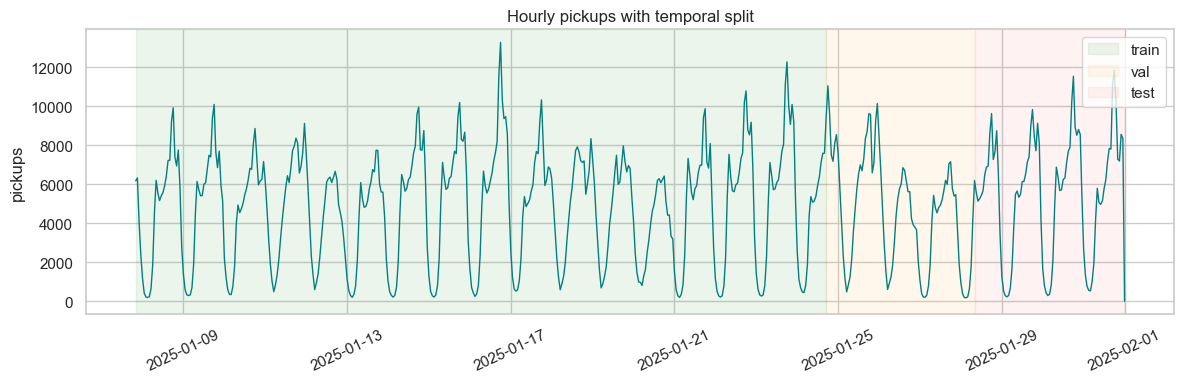

In [21]:
# 8.1 Hourly demand timeline with split shading
citywide = model_df.groupby("pickup_hour", observed=True)["pickup_count"].sum().reset_index()

unique_hours = np.sort(model_df["pickup_hour"].unique())
train_end = unique_hours[int(len(unique_hours) * 0.70) - 1]
val_end = unique_hours[int(len(unique_hours) * 0.85) - 1]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(citywide["pickup_hour"], citywide["pickup_count"], color="teal", lw=1)
ax.axvspan(citywide["pickup_hour"].min(), train_end, color="green", alpha=0.08, label="train")
ax.axvspan(train_end, val_end, color="orange", alpha=0.08, label="val")
ax.axvspan(val_end, citywide["pickup_hour"].max(), color="red", alpha=0.05, label="test")
ax.set_title("Hourly pickups with temporal split")
ax.set_ylabel("pickups")
ax.legend(loc="upper right")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


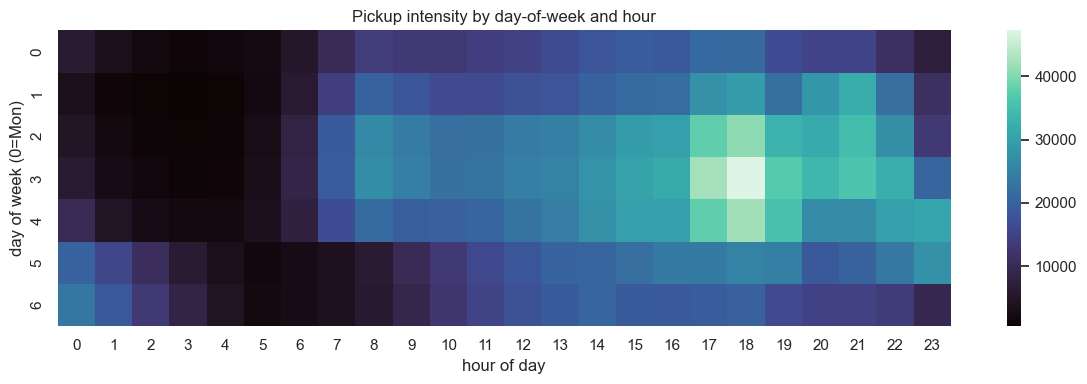

In [22]:
# 8.2 Hour-of-day × day-of-week heatmap (citywide)
heat = (
    model_df.groupby(["dow", "hour"], observed=True)["pickup_count"].sum()
    .reset_index()
    .pivot(index="dow", columns="hour", values="pickup_count")
)

plt.figure(figsize=(12, 4))
sns.heatmap(heat, cmap="mako")
plt.title("Pickup intensity by day-of-week and hour")
plt.xlabel("hour of day")
plt.ylabel("day of week (0=Mon)")
plt.tight_layout()
plt.show()


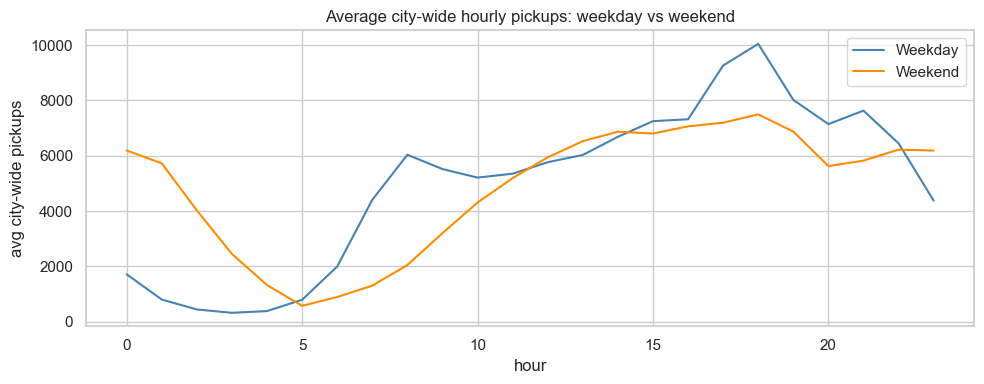

In [23]:
# 8.3 Weekday vs weekend profiles (city-wide)
# Step 1: collapse zone-hour rows into one city-wide total per hour timestamp
city_hourly = (
    model_df.groupby("pickup_hour", observed=True)["pickup_count"]
    .sum()
    .reset_index(name="city_pickups")
)
city_hourly["hour"] = city_hourly["pickup_hour"].dt.hour
city_hourly["is_weekend"] = (city_hourly["pickup_hour"].dt.dayofweek >= 5).astype(int)

# Step 2: average city-wide totals by hour-of-day, split weekday/weekend
profile = (
    city_hourly.groupby(["is_weekend", "hour"], observed=True)["city_pickups"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
for flag, label, color in [(0, "Weekday", "steelblue"), (1, "Weekend", "darkorange")]:
    sub = profile[profile["is_weekend"] == flag]
    ax.plot(sub["hour"], sub["city_pickups"], label=label, color=color)

ax.set_title("Average city-wide hourly pickups: weekday vs weekend")
ax.set_xlabel("hour")
ax.set_ylabel("avg city-wide pickups")
ax.legend()
plt.tight_layout()
plt.show()


Test set — micro-MAE over all zone-hour rows:
  XGBoost          3.5930  (trips per zone-hour, avg abs error)
  Seasonal lag168  4.4856

Macro-MAE (unweighted mean of per-zone MAE): 3.5930
(High macro with lower micro means a few busy zones dominate micro error.)

Hardest 12 zones (highest XGB MAE):


,Zone,PULocationID,n_test_hours,mean_actual,mae_xgb,mae_lag168,delta_mae_lag_minus_xgb
0,Penn Station/Madison Sq West (ID 186),186,113,168.549,33.129,42.283,9.154
1,JFK Airport (ID 132),132,113,178.761,32.870,50.451,17.581
2,Upper East Side South (ID 237),237,113,276.274,29.633,42.956,13.323
3,Midtown Center (ID 161),161,113,290.602,29.511,44.301,14.790
4,Lincoln Square East (ID 142),142,113,162.504,27.182,33.035,5.853
5,Upper East Side North (ID 236),236,113,252.301,24.451,34.779,10.328
6,East Village (ID 79),79,113,93.770,23.619,24.770,1.151
7,Midtown East (ID 162),162,113,202.947,23.616,30.159,6.543
8,LaGuardia Airport (ID 138),138,113,128.000,22.954,31.885,8.931
9,Times Sq/Theatre District (ID 230),230,113,170.912,22.906,27.097,4.191


Easiest 10 zones among those with ≥80 test hours (lowest XGB MAE):


,Zone,PULocationID,n_test_hours,mean_actual,mae_xgb,mae_lag168,delta_mae_lag_minus_xgb
252,Oakwood (ID 176),176,113,0.0,0.104,0.000,-0.104
253,Arden Heights (ID 5),5,113,0.0,0.104,0.000,-0.104
254,Charleston/Tottenville (ID 44),44,113,0.0,0.104,0.000,-0.104
255,Rikers Island (ID 199),199,113,0.0,0.104,0.000,-0.104
256,Rossville/Woodrow (ID 204),204,113,0.0,0.104,0.000,-0.104
257,Freshkills Park (ID 99),99,113,0.0,0.104,0.000,-0.104
258,Eltingville/Annadale/Prince's Bay (ID 84),84,113,0.0,0.104,0.000,-0.104
259,West Brighton (ID 245),245,113,0.0,0.104,0.000,-0.104
260,Green-Wood Cemetery (ID 111),111,113,0.0,0.104,0.000,-0.104
251,Breezy Point/Fort Tilden/Riis Beach (ID 27),27,113,0.0,0.106,0.009,-0.097


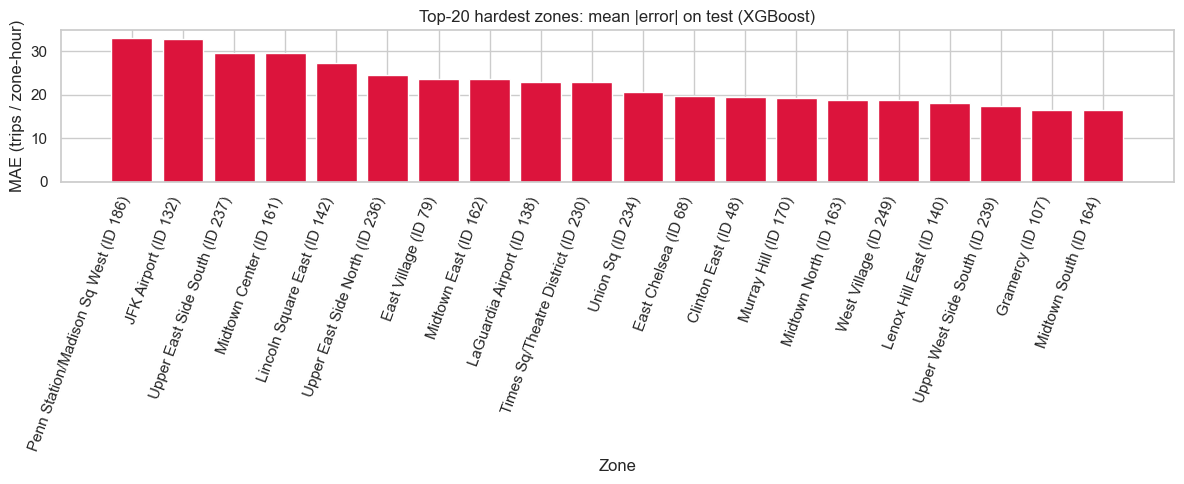

In [24]:
# 8.5 Error by zone (test) — zone-specific difficulty
# Each row: one (pickup_hour, zone). Errors are in "trips" in that zone-hour.
try:
    from IPython.display import display
except ImportError:
    display = print

from sklearn.metrics import mean_absolute_error

# Use zone lookup from the benchmark setup if available; otherwise load now.
if "zone_name_map" not in globals():
    from pathlib import Path
    _lookup_candidates = [Path("data/taxi_zone_lookup.csv"), Path("taxi_zone_lookup.csv")]
    _lookup_path = next((p for p in _lookup_candidates if p.exists()), None)
    if _lookup_path is None:
        raise FileNotFoundError(f"taxi_zone_lookup.csv not found. Tried: {_lookup_candidates}")
    _zl = pd.read_csv(_lookup_path)[["LocationID", "Zone"]].dropna()
    zone_name_map = dict(zip(_zl["LocationID"].astype(int), _zl["Zone"].astype(str)))


def zone_label_local(zid: int) -> str:
    return f"{zone_name_map.get(int(zid), 'Unknown Zone')} (ID {int(zid)})"

pred_test = pipe.predict(X[test_mask])
err = model_df.loc[test_mask, ["PULocationID", "pickup_hour", "pickup_count", "pickup_count_lag168h"]].copy()
err["pred_xgb"] = pred_test
err["abs_err_xgb"] = (err["pickup_count"] - err["pred_xgb"]).abs()
err["abs_err_lag168"] = (err["pickup_count"] - err["pickup_count_lag168h"]).abs()

micro_xgb = mean_absolute_error(err["pickup_count"], err["pred_xgb"])
micro_lag168 = mean_absolute_error(err["pickup_count"], err["pickup_count_lag168h"])
print("Test set — micro-MAE over all zone-hour rows:")
print(f"  XGBoost          {micro_xgb:.4f}  (trips per zone-hour, avg abs error)")
print(f"  Seasonal lag168  {micro_lag168:.4f}")

zone_summary = (
    err.groupby("PULocationID", observed=True)
    .agg(
        n_test_hours=("pickup_hour", "size"),
        mean_actual=("pickup_count", "mean"),
        mae_xgb=("abs_err_xgb", "mean"),
        mae_lag168=("abs_err_lag168", "mean"),
    )
    .assign(delta_mae_lag_minus_xgb=lambda d: d["mae_lag168"] - d["mae_xgb"])
    .sort_values("mae_xgb", ascending=False)
)

zone_summary_display = zone_summary.reset_index()
zone_summary_display["Zone"] = zone_summary_display["PULocationID"].map(zone_label_local)
zone_summary_display = zone_summary_display[["Zone", "PULocationID", "n_test_hours", "mean_actual", "mae_xgb", "mae_lag168", "delta_mae_lag_minus_xgb"]]

macro_xgb = zone_summary["mae_xgb"].mean()
print(f"\nMacro-MAE (unweighted mean of per-zone MAE): {macro_xgb:.4f}")
print('(High macro with lower micro means a few busy zones dominate micro error.)\n')

print("Hardest 12 zones (highest XGB MAE):")
display(zone_summary_display.head(12).round(3))

min_hours = 80
stable = zone_summary_display[zone_summary_display["n_test_hours"] >= min_hours]
print(f"Easiest 10 zones among those with ≥{min_hours} test hours (lowest XGB MAE):")
display(stable.nsmallest(10, "mae_xgb").round(3))

plot_df = zone_summary_display.head(20).copy()
plt.figure(figsize=(12, 5))
plt.bar(plot_df["Zone"], plot_df["mae_xgb"], color="crimson")
plt.title("Top-20 hardest zones: mean |error| on test (XGBoost)")
plt.xlabel("Zone")
plt.ylabel("MAE (trips / zone-hour)")
plt.xticks(rotation=70, ha="right")
plt.tight_layout()
plt.show()


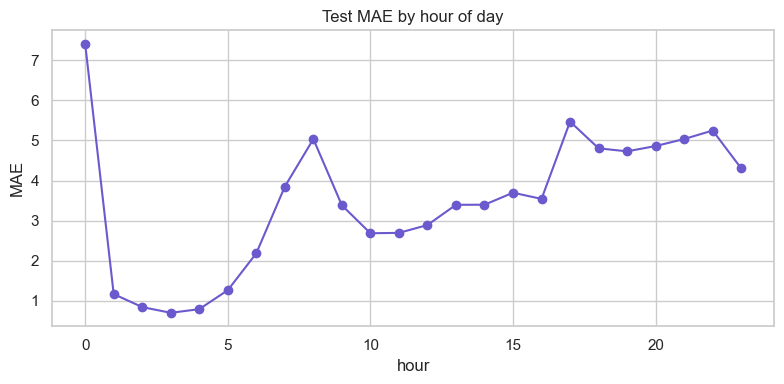

In [25]:
# 8.6 Error by hour (peak vs off-peak)
err = model_df.loc[test_mask, ["hour", "pickup_count"]].copy()
err["pred"] = pred_test
err["abs_err"] = (err["pickup_count"] - err["pred"]).abs()

hour_mae = err.groupby("hour", observed=True)["abs_err"].mean().reset_index()

plt.figure(figsize=(8, 4))
plt.plot(hour_mae["hour"], hour_mae["abs_err"], marker="o", color="slateblue")
plt.title("Test MAE by hour of day")
plt.xlabel("hour")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()


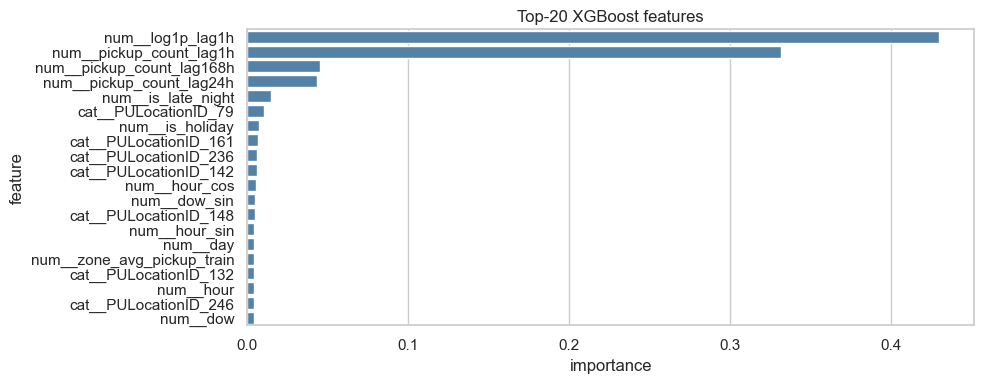

In [26]:
# 8.7 Feature importance (XGBoost gain)
feature_names = pipe.named_steps["prep"].get_feature_names_out()
importances = pipe.named_steps["model"].feature_importances_

imp = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 4))
sns.barplot(data=imp, x="importance", y="feature", color="steelblue")
plt.title("Top-20 XGBoost features")
plt.tight_layout()
plt.show()


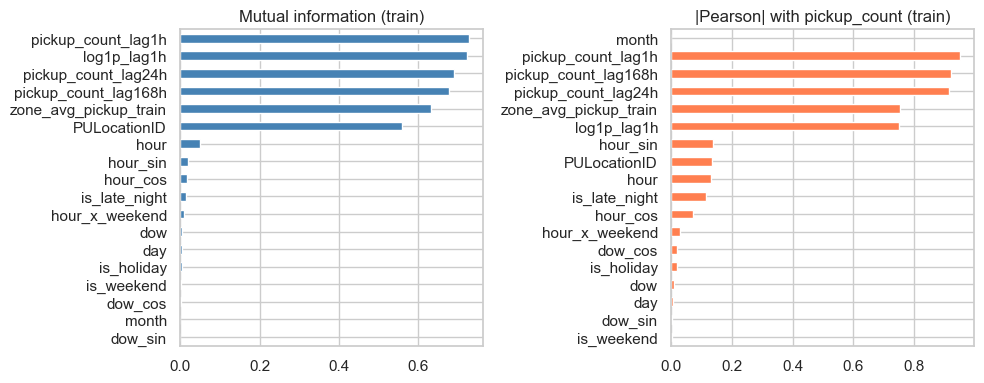

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
selection["mutual_info"].sort_values().plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Mutual information (train)")
selection["abs_pearson"].sort_values().plot.barh(ax=axes[1], color="coral")
axes[1].set_title("|Pearson| with pickup_count (train)")
plt.tight_layout()
plt.show()


## 7. Optional: trip-level chronological split (70% / 15% / 15%)

For **demand forecasting**, prefer the **hour-based** split on `panel_model` in §6b (already applied via the `split` column).

The block below is for **trip-level** tasks (e.g. predict tip or fare per trip): sort trips by `tpep_pickup_datetime`, take the first 70% / next 15% / last 15% of **rows** — no shuffle.


In [28]:
df_model = df_clean.sort_values("tpep_pickup_datetime").reset_index(drop=True)
n = len(df_model)
i1 = int(n * 0.70)
i2 = int(n * 0.85)

train_idx = slice(0, i1)
val_idx = slice(i1, i2)
test_idx = slice(i2, n)

train_df = df_model.iloc[train_idx].copy()
val_df = df_model.iloc[val_idx].copy()
test_df = df_model.iloc[test_idx].copy()

print(f"Total rows: {n:,}")
print(f"Train: {len(train_df):,} ({100*len(train_df)/n:.2f}%) — pickup until {train_df['tpep_pickup_datetime'].max()}")
print(f"Val:   {len(val_df):,} ({100*len(val_df)/n:.2f}%)")
print(f"Test:  {len(test_df):,} ({100*len(test_df)/n:.2f}%) — from {test_df['tpep_pickup_datetime'].min()}")

# Leakage check: max train time <= min val time
assert train_df["tpep_pickup_datetime"].max() <= val_df["tpep_pickup_datetime"].min()
assert val_df["tpep_pickup_datetime"].max() <= test_df["tpep_pickup_datetime"].min()
print("\nTemporal ordering OK (no future trips in train relative to val/test).")


Total rows: 3,472,104
Train: 2,430,472 (70.00%) — pickup until 2025-01-23 15:22:44
Val:   520,816 (15.00%)
Test:  520,816 (15.00%) — from 2025-01-27 19:18:39

Temporal ordering OK (no future trips in train relative to val/test).


## 8. Feature engineering — ideas (especially for `pickup_count`)

You already have a baseline feature set on **`panel_model`**. Strong next steps for **zone-hour demand**:

1. **More history** — §6b (continued) already adds **1h / 24h / 168h lags** on a dense grid; try **rolling mean** (e.g. last 6h) or **EWMA** of lagged counts per zone.
2. **Zone as categorical** — one-hot (sparse) or **embedding** / target encoding; `PULocationID` MI is high but linear models should not treat IDs as a continuous scale.
3. **Holidays / events** — merge a NYC calendar; binary flags or counts.
4. **Weather** — hourly precipitation/temperature joined on `pickup_hour` (external API or archive).
5. **Network effects** — mean/median demand in neighboring zones (from a TLC adjacency or distance matrix), computed with train-only stats.

For **trip-level** models, still use `train_df` only for any encoding fit (§7).

**sklearn:** `ColumnTransformer` + `Pipeline`, `fit` on `panel_model.loc[panel_model["split"]=="train"]` for demand, or on `train_df` for trip tasks.


In [29]:
# Starter: datetime parts (extend in new cells)
def add_time_features(d: pd.DataFrame) -> pd.DataFrame:
    out = d.copy()
    ts = out["tpep_pickup_datetime"]
    out["pickup_hour"] = ts.dt.hour
    out["pickup_dow"] = ts.dt.dayofweek
    out["pickup_month"] = ts.dt.month
    return out

train_fe = add_time_features(train_df)
val_fe = add_time_features(val_df)
test_fe = add_time_features(test_df)
train_fe[["tpep_pickup_datetime", "pickup_hour", "pickup_dow"]].head()


,tpep_pickup_datetime,pickup_hour,pickup_dow
0,2024-12-31 20:47:55,20,1
1,2024-12-31 20:52:50,20,1
2,2024-12-31 20:54:50,20,1
3,2024-12-31 21:15:22,21,1
4,2024-12-31 21:20:05,21,1


## 9. Simple benchmark model: Linear Regression (easy to explain)

Before XGBoost, we fit a plain **Linear Regression** on the same demand panel. This gives a transparent benchmark:

- prediction is a weighted sum of features
- coefficients are directly interpretable (direction + relative influence)
- easy baseline to compare against lag-only rules

For realism and fairness, we train on `split == "train"`, tune/check on `val`, and report on `test`.


In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Keep feature set simple and interpretable
LIN_FEATURES = [
    "pickup_count_lag1h",
    "pickup_count_lag24h",
    "pickup_count_lag168h",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "is_weekend",
    "is_late_night",
    "hour_x_weekend",
    "zone_avg_pickup_train",
    "PULocationID",  # one-hot below
]

lin_df = panel_model[["pickup_count", "split"] + LIN_FEATURES].copy()
lin_df = pd.get_dummies(lin_df, columns=["PULocationID"], drop_first=True)

train_m = lin_df["split"].eq("train")
val_m = lin_df["split"].eq("val")
test_m = lin_df["split"].eq("test")

X_cols = [c for c in lin_df.columns if c not in ["pickup_count", "split"]]
X_train, y_train = lin_df.loc[train_m, X_cols], lin_df.loc[train_m, "pickup_count"]
X_val, y_val = lin_df.loc[val_m, X_cols], lin_df.loc[val_m, "pickup_count"]
X_test, y_test = lin_df.loc[test_m, X_cols], lin_df.loc[test_m, "pickup_count"]

lin = LinearRegression()
lin.fit(X_train, y_train)

y_val_hat = np.clip(lin.predict(X_val), 0, None)
y_test_hat = np.clip(lin.predict(X_test), 0, None)

def report_split(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    print(f"{name}: MAE={mae:.3f}, RMSE={rmse:.3f}")

print("Linear Regression performance")
report_split("Val", y_val, y_val_hat)
report_split("Test", y_test, y_test_hat)



Linear Regression performance
Val: MAE=4.780, RMSE=14.922
Test: MAE=4.337, RMSE=14.337


In [31]:
# Compare to simple lag-only baselines on the same test rows
def baseline_mae(y_true, pred):
    return mean_absolute_error(y_true, np.clip(pred, 0, None))

test_rows = panel_model.loc[panel_model["split"].eq("test")].copy()

mae_lag1 = baseline_mae(test_rows["pickup_count"], test_rows["pickup_count_lag1h"])
mae_lag24 = baseline_mae(test_rows["pickup_count"], test_rows["pickup_count_lag24h"])
mae_lag168 = baseline_mae(test_rows["pickup_count"], test_rows["pickup_count_lag168h"])
mae_lin = mean_absolute_error(y_test, y_test_hat)

print("Test MAE comparison")
print(f"  Lag-1h baseline   : {mae_lag1:.3f}")
print(f"  Lag-24h baseline  : {mae_lag24:.3f}")
print(f"  Lag-168h baseline : {mae_lag168:.3f}")
print(f"  Linear Regression : {mae_lin:.3f}")



Test MAE comparison
  Lag-1h baseline   : 5.982
  Lag-24h baseline  : 5.108
  Lag-168h baseline : 4.486
  Linear Regression : 4.337


**How to explain this in your status report:** Linear Regression is a transparent midpoint between pure lag rules and XGBoost. If it beats seasonal baselines, you show that combining lag + time + zone information linearly already adds value; then XGBoost is justified as a non-linear upgrade.


---

## How everything was done (methodology recap)

**Loading and schema** — We used `pandas.read_parquet` (PyArrow engine) to preserve dtypes. The feature table lists dtypes and null percentages so we know which columns need imputation vs. filtering.

**EDA philosophy** — Summary statistics (`describe`) plus **joint missingness** checks avoid treating missing values as independent when TLC often drops a **bundle** of fields per vendor.

**Derived sanity features** — Duration and implied speed connect distance and time; extremes where distance is huge but duration is tiny are almost never real door-to-door NYC trips at sustained speed.

**Outliers** — We separated *exploration* (quantiles, top-`n` rows, payment/vendor slices) from *decisions* (thresholds in `RULES`). Thresholds are **domain-tuned**: you might keep airport long-hauls by raising caps or excluding by `RatecodeID`.

**Imputation** — Grouped medians by `VendorID` acknowledge different reporting behavior. Surcharges default to 0 when null after vendor adjustment where appropriate; `store_and_fwd_flag` defaults to `'N'` (most trips are not stored).

**Hourly normalization** — Citywide `hourly` uses `pd.Grouper(freq="h")`. The **modeling target** is the **zone-hour panel** `demand_panel`: `pickup_count` = trips per `(pickup_hour, PULocationID)` from `df_clean`.

**Train/val/test (demand)** — Sort **distinct** `pickup_hour` values; first 70% of hours → train, next 15% → val, last 15% → test. Every `(hour, zone)` row inherits its hour’s split so models do not train on future time.

**Lags & engineered columns** — Full zone × hour grid with zeros in gaps; `shift(1/24/168)` per zone. Plus `is_late_night`, `hour_x_weekend`, `zone_avg_pickup_train` (train-only zone mean), `log1p_lag1h`.

**Feature selection** — Same metrics on **train** rows only; **lag-1h** usually dominates MI (autocorrelation in demand).

**Trip-level split (optional)** — §7 for trip tasks; use `train_fe` / `val_fe` / `test_fe` or keep building on `panel_model`.


## 10. Advanced benchmark: ARIMA vs Prophet vs XGBoost vs TimeMCL

This section extends the earlier baseline work with a **like-for-like benchmark** on the cleaned zone-hour panel.

### Benchmark protocol
- Evaluate on **top-K busiest zones** (selected using **train split only**).
- Keep one common chronology and one common metric implementation for all models.
- Report **MAE** and **MAPE** where `MAPE = mean(|y - yhat| / max(y, 1)) * 100`.
- Include classical models (**ARIMA**, **Prophet**) and ML models (**XGBoost**, **TimeMCL**).

> This gives a fair, leakage-safe comparison across paradigms while keeping runtime practical in a notebook.


In [32]:
# If needed (uncomment):
%pip install -q statsmodels prophet torch xgboost


import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error

warnings.filterwarnings("ignore")
np.random.seed(42)



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [33]:

# ---- Shared benchmark configuration + audit ----
from pathlib import Path

REQUIRED_COLS = {"pickup_hour", "PULocationID", "pickup_count", "split"}
missing = REQUIRED_COLS - set(model_df.columns)
if missing:
    raise ValueError(f"model_df is missing required columns: {missing}")

TOP_K_ZONES = 8          # Increase for broader coverage (runtime will increase)
WINDOW = 24              # History length for TimeMCL windows
HORIZON = 1              # One-step-ahead forecasting target
NUM_HYPS = 8             # TimeMCL number of hypotheses
TIME_MCL_EPOCHS = 12     # Increase for stronger convergence
TIME_MCL_BATCH = 128
TIME_MCL_LR = 1e-3

# Resolve zone lookup path robustly (works from repo root or data/ cwd)
_lookup_candidates = [
    Path("data/taxi_zone_lookup.csv"),
    Path("taxi_zone_lookup.csv"),
]
_lookup_path = next((p for p in _lookup_candidates if p.exists()), None)
if _lookup_path is None:
    raise FileNotFoundError(f"taxi_zone_lookup.csv not found. Tried: {_lookup_candidates}")

zone_lookup = pd.read_csv(_lookup_path)[["LocationID", "Zone"]].dropna()
zone_name_map = dict(zip(zone_lookup["LocationID"].astype(int), zone_lookup["Zone"].astype(str)))

def zone_label(zid: int) -> str:
    return f"{zone_name_map.get(int(zid), 'Unknown Zone')} (ID {int(zid)})"

# Ensure deterministic row order
bench_df = model_df.sort_values(["PULocationID", "pickup_hour"]).copy()

# Top-K busiest zones selected on train only (leakage-safe)
train_zone_mass = (
    bench_df.loc[bench_df["split"] == "train"]
    .groupby("PULocationID", observed=True)["pickup_count"]
    .sum()
    .sort_values(ascending=False)
)
top_zones = train_zone_mass.head(TOP_K_ZONES).index.to_list()
bench_top = bench_df[bench_df["PULocationID"].isin(top_zones)].copy()

print(f"Top-{TOP_K_ZONES} zones (train demand): {[zone_label(z) for z in top_zones]}")
print(bench_top["split"].value_counts().to_dict())


Top-8 zones (train demand): ['Midtown Center (ID 161)', 'Upper East Side South (ID 237)', 'Upper East Side North (ID 236)', 'JFK Airport (ID 132)', 'Times Sq/Theatre District (ID 230)', 'Penn Station/Madison Sq West (ID 186)', 'Midtown East (ID 162)', 'Lincoln Square East (ID 142)']
{'train': 2848, 'test': 904, 'val': 896}


In [34]:
# ---- Unified evaluation harness ----
def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true), 1.0)
    return float(np.mean(np.abs(y_true - y_pred) / denom) * 100.0)


def metrics_dict(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "MAPE": safe_mape(y_true, y_pred),
    }


def evaluate_predictions(pred_long: pd.DataFrame) -> pd.DataFrame:
    req = {"model", "PULocationID", "pickup_hour", "y_true", "y_pred"}
    miss = req - set(pred_long.columns)
    if miss:
        raise ValueError(f"pred_long missing: {miss}")

    rows = []
    for (m, z), g in pred_long.groupby(["model", "PULocationID"], observed=True):
        mt = metrics_dict(g["y_true"], g["y_pred"])
        rows.append({"model": m, "zone": int(z), **mt, "n": int(len(g))})

    # Macro across zones
    per_zone = pd.DataFrame(rows)
    macro = (
        per_zone.groupby("model", observed=True)[["MAE", "MAPE"]]
        .mean()
        .reset_index()
        .assign(zone="macro_avg", n=per_zone.groupby("model", observed=True)["n"].sum().values)
    )

    # Micro across all rows
    micro_rows = []
    for m, g in pred_long.groupby("model", observed=True):
        mt = metrics_dict(g["y_true"], g["y_pred"])
        micro_rows.append({"model": m, "zone": "micro_all", **mt, "n": int(len(g))})

    out = pd.concat([per_zone, macro, pd.DataFrame(micro_rows)], ignore_index=True)
    return out.sort_values(["model", "zone"]).reset_index(drop=True)


# Container for model outputs in one long table
pred_frames = []


In [35]:
# ---- ARIMA (per-zone, top-K) ----
from statsmodels.tsa.statespace.sarimax import SARIMAX


def fit_arima_zone(train_s, val_s):
    candidates = [
        ((1,0,1),(1,0,1,24)),
        ((2,0,1),(1,0,1,24)),
        ((1,1,1),(1,0,1,24)),
    ]
    best = None
    best_mae = np.inf

    for order, sorder in candidates:
        try:
            mdl = SARIMAX(
                train_s.astype(float),
                order=order,
                seasonal_order=sorder,
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit(disp=False)
            if len(val_s) > 0:
                pred_val = mdl.forecast(steps=len(val_s))
                mae = mean_absolute_error(val_s.values, np.clip(pred_val.values, 0, None))
            else:
                mae = mdl.aic
            if mae < best_mae:
                best_mae = mae
                best = (order, sorder)
        except Exception:
            continue

    if best is None:
        best = ((1,0,1),(1,0,1,24))
    return best


arima_rows = []
for zone in top_zones:
    z = bench_top[bench_top["PULocationID"] == zone].sort_values("pickup_hour")
    tr = z[z["split"] == "train"].set_index("pickup_hour")["pickup_count"]
    va = z[z["split"] == "val"].set_index("pickup_hour")["pickup_count"]
    te = z[z["split"] == "test"].set_index("pickup_hour")["pickup_count"]

    order, sorder = fit_arima_zone(tr, va)
    train_plus_val = pd.concat([tr, va])

    try:
        mdl = SARIMAX(
            train_plus_val.astype(float),
            order=order,
            seasonal_order=sorder,
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False)
        pred = np.clip(mdl.forecast(steps=len(te)).values, 0, None)
    except Exception:
        # Fallback to seasonal naive if optimizer fails
        pred = np.clip(te.shift(24).fillna(te.shift(1)).fillna(0).values, 0, None)

    arima_rows.append(pd.DataFrame({
        "model": "ARIMA",
        "PULocationID": zone,
        "pickup_hour": te.index.values,
        "y_true": te.values,
        "y_pred": pred,
    }))

arima_pred = pd.concat(arima_rows, ignore_index=True)
pred_frames.append(arima_pred)
print("ARIMA done:", arima_pred.shape)


/Users/firasastwani/Desktop/Data Mining/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/firasastwani/Desktop/Data Mining/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/firasastwani/Desktop/Data Mining/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/firasastwani/Desktop/Data Mining/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Users/firasastwani/Desktop/Data Mining/.venv/lib/py

ARIMA done: (904, 5)


In [36]:
# ---- Prophet (per-zone, top-K) ----
prophet_available = True
try:
    from prophet import Prophet
except Exception:
    prophet_available = False
    print("Prophet not available. Install with: pip install prophet")

prophet_rows = []
if prophet_available:
    for zone in top_zones:
        z = bench_top[bench_top["PULocationID"] == zone].sort_values("pickup_hour")
        tr = z[z["split"] == "train"][["pickup_hour", "pickup_count"]].rename(columns={"pickup_hour": "ds", "pickup_count": "y"})
        va = z[z["split"] == "val"][["pickup_hour", "pickup_count"]].rename(columns={"pickup_hour": "ds", "pickup_count": "y"})
        te = z[z["split"] == "test"][["pickup_hour", "pickup_count"]].rename(columns={"pickup_hour": "ds", "pickup_count": "y"})

        train_fit = pd.concat([tr, va], ignore_index=True)

        m = Prophet(
            growth="linear",
            daily_seasonality=True,
            weekly_seasonality=True,
            yearly_seasonality=False,
            changepoint_prior_scale=0.05,
            seasonality_mode="additive",
        )
        m.fit(train_fit)

        future = pd.DataFrame({"ds": te["ds"].values})
        fcst = m.predict(future)
        pred = np.clip(fcst["yhat"].values, 0, None)

        prophet_rows.append(pd.DataFrame({
            "model": "Prophet",
            "PULocationID": zone,
            "pickup_hour": te["ds"].values,
            "y_true": te["y"].values,
            "y_pred": pred,
        }))

if prophet_rows:
    prophet_pred = pd.concat(prophet_rows, ignore_index=True)
    pred_frames.append(prophet_pred)
    print("Prophet done:", prophet_pred.shape)


Importing plotly failed. Interactive plots will not work.
22:37:32 - cmdstanpy - INFO - Chain [1] start processing
22:37:32 - cmdstanpy - INFO - Chain [1] done processing
22:37:33 - cmdstanpy - INFO - Chain [1] start processing
22:37:33 - cmdstanpy - INFO - Chain [1] done processing
22:37:33 - cmdstanpy - INFO - Chain [1] start processing
22:37:33 - cmdstanpy - INFO - Chain [1] done processing
22:37:33 - cmdstanpy - INFO - Chain [1] start processing
22:37:33 - cmdstanpy - INFO - Chain [1] done processing
22:37:33 - cmdstanpy - INFO - Chain [1] start processing
22:37:33 - cmdstanpy - INFO - Chain [1] done processing
22:37:33 - cmdstanpy - INFO - Chain [1] start processing
22:37:33 - cmdstanpy - INFO - Chain [1] done processing
22:37:33 - cmdstanpy - INFO - Chain [1] start processing
22:37:33 - cmdstanpy - INFO - Chain [1] done processing
22:37:33 - cmdstanpy - INFO - Chain [1] start processing
22:37:33 - cmdstanpy - INFO - Chain [1] done processing


Prophet done: (904, 5)


In [37]:
# ---- XGBoost (reuse existing model output if available; else train quickly) ----
xgb_subset = None
if "pred_xgb" in model_df.columns:
    xgb_subset = model_df.loc[
        (model_df["split"].eq("test")) & (model_df["PULocationID"].isin(top_zones)),
        ["PULocationID", "pickup_hour", "pickup_count", "pred_xgb"]
    ].copy()
    xgb_subset = xgb_subset.rename(columns={"pickup_count": "y_true", "pred_xgb": "y_pred"})
else:
    # Refit pooled model if `pred_xgb` is not already materialized.
    # If xgboost cannot load (e.g., missing libomp on macOS), fallback to sklearn GBR.
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder
    from sklearn.ensemble import HistGradientBoostingRegressor

    CAT_COLS = ["PULocationID"]
    NUM_COLS = [
        "hour", "dow", "month", "day", "is_weekend", "hour_sin", "hour_cos", "dow_sin", "dow_cos",
        "pickup_count_lag1h", "pickup_count_lag24h", "pickup_count_lag168h", "zone_avg_pickup_train", "log1p_lag1h"
    ]
    avail_num = [c for c in NUM_COLS if c in model_df.columns]
    X = model_df[CAT_COLS + avail_num]
    y = model_df["pickup_count"]

    tr = model_df["split"].eq("train")
    te = model_df["split"].eq("test")

    pre = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_COLS),
        ("num", "passthrough", avail_num),
    ], remainder="drop")

    reg = None
    model_name = "XGBoost"
    try:
        from xgboost import XGBRegressor
        reg = XGBRegressor(
            n_estimators=350,
            max_depth=8,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="reg:squarederror",
            random_state=42,
        )
    except Exception as e:
        print(f"xgboost unavailable ({e}). Falling back to HistGradientBoostingRegressor.")
        reg = HistGradientBoostingRegressor(
            max_depth=12,
            learning_rate=0.05,
            max_iter=500,
            random_state=42,
        )
        model_name = "GBRT_fallback"

    pipe = Pipeline([("pre", pre), ("reg", reg)])
    pipe.fit(X[tr], y[tr])

    pred_test = np.clip(pipe.predict(X[te]), 0, None)
    tmp = model_df.loc[te, ["PULocationID", "pickup_hour", "pickup_count"]].copy()
    tmp["pred_xgb"] = pred_test
    xgb_subset = tmp.loc[tmp["PULocationID"].isin(top_zones)].rename(columns={"pickup_count": "y_true", "pred_xgb": "y_pred"})
    xgb_subset["model"] = model_name

if "model" not in xgb_subset.columns:
    xgb_subset["model"] = "XGBoost"
xgb_subset = xgb_subset[["model", "PULocationID", "pickup_hour", "y_true", "y_pred"]].reset_index(drop=True)
pred_frames.append(xgb_subset)
print("Boosted-tree model done:", xgb_subset.shape, "|", xgb_subset["model"].iloc[0])


Boosted-tree model done: (904, 5) | XGBoost


In [45]:
# ---- TimeMCL (imported module: point + probabilistic outputs) ----
import importlib
import time
import timemcl_benchmark as tmcl_mod

_t0 = time.perf_counter()
tmcl_mod = importlib.reload(tmcl_mod)
print(f"Loaded timemcl_benchmark from: {tmcl_mod.__file__}")
TimeMCLConfig = tmcl_mod.TimeMCLConfig
train_time_mcl_on_panel = tmcl_mod.train_time_mcl_on_panel
build_timemcl_outputs = tmcl_mod.build_timemcl_outputs
probabilistic_scores = tmcl_mod.probabilistic_scores

# Higher-capacity run to improve TimeMCL point performance
cfg = TimeMCLConfig(
    window=WINDOW,
    horizon=HORIZON,
    num_hyps=NUM_HYPS,
    hidden=256,
    epochs=max(TIME_MCL_EPOCHS, 40),
    batch_size=64,
    lr=8e-4,
    seed=42,
    temp_start=4.0,
    temp_end=0.35,
    diversity_weight=0.12,
    balance_weight=0.05,
    max_train_windows=None,  # full available train windows
    verbose=True,
    progress_every=1,
    weight_decay=1e-5,
    grad_clip_norm=1.0,
    dropout=0.1,
    early_stopping_patience=10,
)
print("Starting TimeMCL training with config:", cfg)

state = train_time_mcl_on_panel(bench_top, top_zones, cfg)
print(f"Training finished in {time.perf_counter() - _t0:.2f}s")

# Better point extraction for MAE comparison: choose best head by validation MAE per zone
tmcl_pred, tmcl_prob = build_timemcl_outputs(state, point_policy="val_best_head")

# Keep point forecast in the common benchmark table (replace previous TimeMCL rows on rerun)
pred_frames = [df for df in pred_frames if not ("model" in df.columns and (df["model"] == "TimeMCL").any())]
pred_frames.append(tmcl_pred)

# New: keep full probabilistic outputs for uncertainty diagnostics
tmcl_prob_scores = probabilistic_scores(tmcl_prob)

print("TimeMCL point done:", tmcl_pred.shape)
print("TimeMCL probabilistic rows:", tmcl_prob.shape)
print("Best val loss:", round(min(state["val_trace"]), 4))
display(tmcl_prob_scores)


Loaded timemcl_benchmark from: /Users/firasastwani/Desktop/Data Mining/timemcl_benchmark.py
Starting TimeMCL training with config: TimeMCLConfig(window=24, horizon=1, num_hyps=8, hidden=256, epochs=40, batch_size=64, lr=0.0008, seed=42, temp_start=4.0, temp_end=0.35, diversity_weight=0.12, max_train_windows=None, verbose=True, progress_every=1, weight_decay=1e-05, grad_clip_norm=1.0, dropout=0.1, early_stopping_patience=10, balance_weight=0.05)
[TimeMCL] entering train_time_mcl_on_panel | rows=4,648 | zones=8 | window=24 | horizon=1
[TimeMCL] device resolved: cpu
[TimeMCL] panel reduced for pivot | rows=4,648
[TimeMCL] wide matrix built | hours=581 | time_span=(2025-01-07 20:00:00 -> 2025-02-01 00:00:00)
[TimeMCL] standardized matrix ready | arr_shape=(581, 8)
[TimeMCL] device=cpu | n_feat=8 | windows(train/val/test)=332/112/113
[TimeMCL] epoch 01/40 | temp=4.0000 | train_loss=0.9520 | val_loss=0.7189 | lr=7.99e-04
[TimeMCL] epoch 02/40 | temp=3.7578 | train_loss=0.5259 | val_loss=0.39

,model,PULocationID,pinball_q10,pinball_q50,pinball_q90,coverage_10_90,mean_width_10_90
0,TimeMCL,132,13.437660,15.231172,9.410445,0.309735,26.140819
1,TimeMCL,142,9.336454,13.854718,9.518857,0.442478,29.455501
2,TimeMCL,161,9.046318,15.534959,11.696307,0.495575,37.500944
3,TimeMCL,162,5.123632,11.417291,9.633476,0.513274,27.401411
4,TimeMCL,186,15.933751,17.217126,10.326580,0.283186,27.927129
5,TimeMCL,230,14.261450,14.748821,5.821440,0.371681,30.685948
6,TimeMCL,236,9.801936,13.163550,9.061424,0.451327,31.346160
7,TimeMCL,237,6.527171,13.896767,12.452079,0.442478,32.599949
8,TimeMCL,macro_avg,10.433547,14.383051,9.740076,0.413717,30.382233


In [47]:
# ---- Final comparison table (point metrics) ----
pred_long = pd.concat(pred_frames, ignore_index=True)
pred_long["y_pred"] = np.clip(pred_long["y_pred"].astype(float), 0.0, None)
pred_long["y_true"] = pred_long["y_true"].astype(float)

benchmark_scores = evaluate_predictions(pred_long)

summary = benchmark_scores[benchmark_scores["zone"].isin(["macro_avg", "micro_all"])].copy()
summary = summary.sort_values(["zone", "MAE"]).reset_index(drop=True)

print("=== Aggregate benchmark (lower is better) ===")
display(summary)

print("=== TimeMCL probabilistic diagnostics (lower pinball is better; coverage near 0.8 is desirable for 10-90 band) ===")
display(tmcl_prob_scores)


=== Aggregate benchmark (lower is better) ===


,model,zone,MAE,MAPE,n
0,XGBoost,macro_avg,29.239359,139.038178,904
1,TimeMCL,macro_avg,30.298491,144.144615,904
2,Prophet,macro_avg,48.969995,261.238819,904
3,ARIMA,macro_avg,88.134194,105.613668,904
4,XGBoost,micro_all,29.239359,139.038178,904
5,TimeMCL,micro_all,30.298491,144.144615,904
6,Prophet,micro_all,48.969995,261.238819,904
7,ARIMA,micro_all,88.134194,105.613668,904


=== TimeMCL probabilistic diagnostics (lower pinball is better; coverage near 0.8 is desirable for 10-90 band) ===


,model,PULocationID,pinball_q10,pinball_q50,pinball_q90,coverage_10_90,mean_width_10_90
0,TimeMCL,132,13.437660,15.231172,9.410445,0.309735,26.140819
1,TimeMCL,142,9.336454,13.854718,9.518857,0.442478,29.455501
2,TimeMCL,161,9.046318,15.534959,11.696307,0.495575,37.500944
3,TimeMCL,162,5.123632,11.417291,9.633476,0.513274,27.401411
4,TimeMCL,186,15.933751,17.217126,10.326580,0.283186,27.927129
5,TimeMCL,230,14.261450,14.748821,5.821440,0.371681,30.685948
6,TimeMCL,236,9.801936,13.163550,9.061424,0.451327,31.346160
7,TimeMCL,237,6.527171,13.896767,12.452079,0.442478,32.599949
8,TimeMCL,macro_avg,10.433547,14.383051,9.740076,0.413717,30.382233


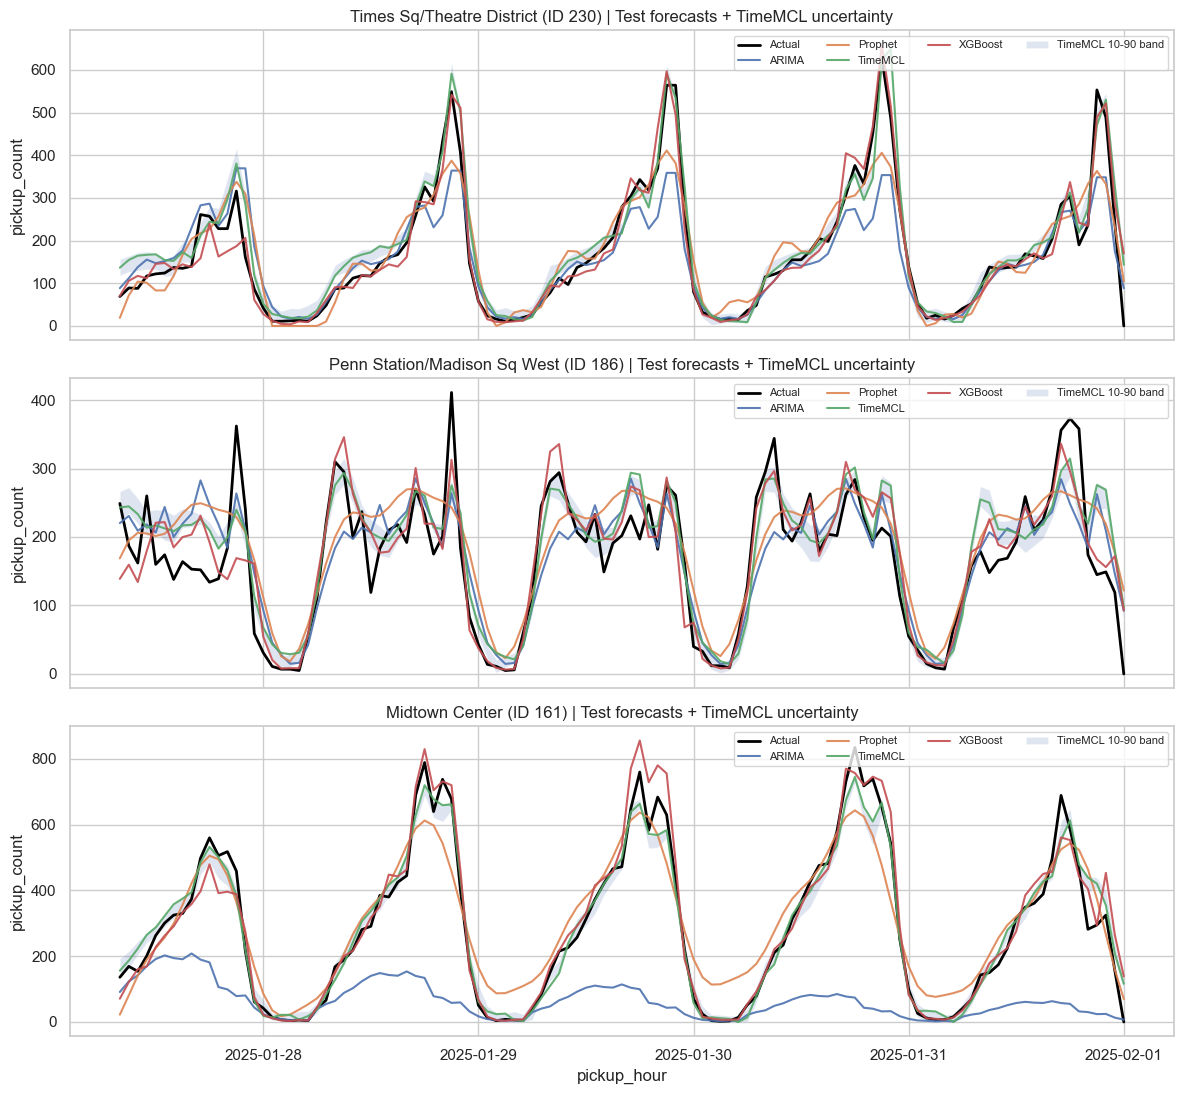

TimeMCL now outputs full hypothesis forecasts; table stays point-based for comparability, while this plot shows uncertainty spread.


In [48]:
# ---- Visual comparison on representative zones + TimeMCL uncertainty band ----
if "zone_name_map" not in globals():
    from pathlib import Path
    _lookup_candidates = [Path("data/taxi_zone_lookup.csv"), Path("taxi_zone_lookup.csv")]
    _lookup_path = next((p for p in _lookup_candidates if p.exists()), None)
    if _lookup_path is None:
        raise FileNotFoundError(f"taxi_zone_lookup.csv not found. Tried: {_lookup_candidates}")
    _zl = pd.read_csv(_lookup_path)[["LocationID", "Zone"]].dropna()
    zone_name_map = dict(zip(_zl["LocationID"].astype(int), _zl["Zone"].astype(str)))

def zone_label(zid: int) -> str:
    return f"{zone_name_map.get(int(zid), 'Unknown Zone')} (ID {int(zid)})"

zone_rank = (
    benchmark_scores[(benchmark_scores["model"].astype(str).isin(["XGBoost", "GBRT_fallback"])) & (benchmark_scores["zone"].astype(str).str.isnumeric())]
    .sort_values("MAE")
)
if len(zone_rank) >= 3:
    rep_zones = [int(zone_rank.iloc[0]["zone"]), int(zone_rank.iloc[len(zone_rank)//2]["zone"]), int(zone_rank.iloc[-1]["zone"])]
else:
    rep_zones = top_zones[:3]

fig, axes = plt.subplots(len(rep_zones), 1, figsize=(12, 3.7 * len(rep_zones)), sharex=True)
if len(rep_zones) == 1:
    axes = [axes]

for ax, zone in zip(axes, rep_zones):
    d = pred_long[pred_long["PULocationID"] == zone].sort_values("pickup_hour")
    truth = d[d["model"] == d["model"].iloc[0]][["pickup_hour", "y_true"]].drop_duplicates()
    ax.plot(truth["pickup_hour"], truth["y_true"], label="Actual", linewidth=2, color="black")

    for m in sorted(d["model"].unique()):
        dm = d[d["model"] == m]
        ax.plot(dm["pickup_hour"], dm["y_pred"], label=m, alpha=0.9)

    # TimeMCL uncertainty (10-90 quantile band from hypotheses)
    zp = tmcl_prob[tmcl_prob["PULocationID"] == zone]
    piv = zp.pivot_table(index="pickup_hour", columns="hypothesis", values="y_pred_h").sort_index()
    if len(piv) > 0:
        q10 = np.quantile(piv.values, 0.10, axis=1)
        q90 = np.quantile(piv.values, 0.90, axis=1)
        ax.fill_between(piv.index, q10, q90, alpha=0.18, label="TimeMCL 10-90 band")

    ax.set_title(f"{zone_label(zone)} | Test forecasts + TimeMCL uncertainty")
    ax.set_ylabel("pickup_count")
    ax.legend(ncol=4, fontsize=8, loc="upper right")

axes[-1].set_xlabel("pickup_hour")
plt.tight_layout()
plt.show()

print("TimeMCL now outputs full hypothesis forecasts; table stays point-based for comparability, while this plot shows uncertainty spread.")


### 10b. TimeMCL hypotheses view (repo-style multiple futures)

This plot shows **all `k` hypotheses explicitly** (one line per head) for selected zones over the test window, instead of collapsing to a single point forecast.

- Thin colored lines: each TimeMCL hypothesis (`h=0..k-1`)
- Black line: observed demand
- Dashed line: TimeMCL median across hypotheses

This mirrors the repository spirit of visualizing diverse plausible futures rather than only one deterministic trajectory.


Selected TimeMCL zones (best2 + worst2 by MAE): ['Midtown East (ID 162)', 'Lincoln Square East (ID 142)', 'Upper East Side North (ID 236)', 'Penn Station/Madison Sq West (ID 186)']


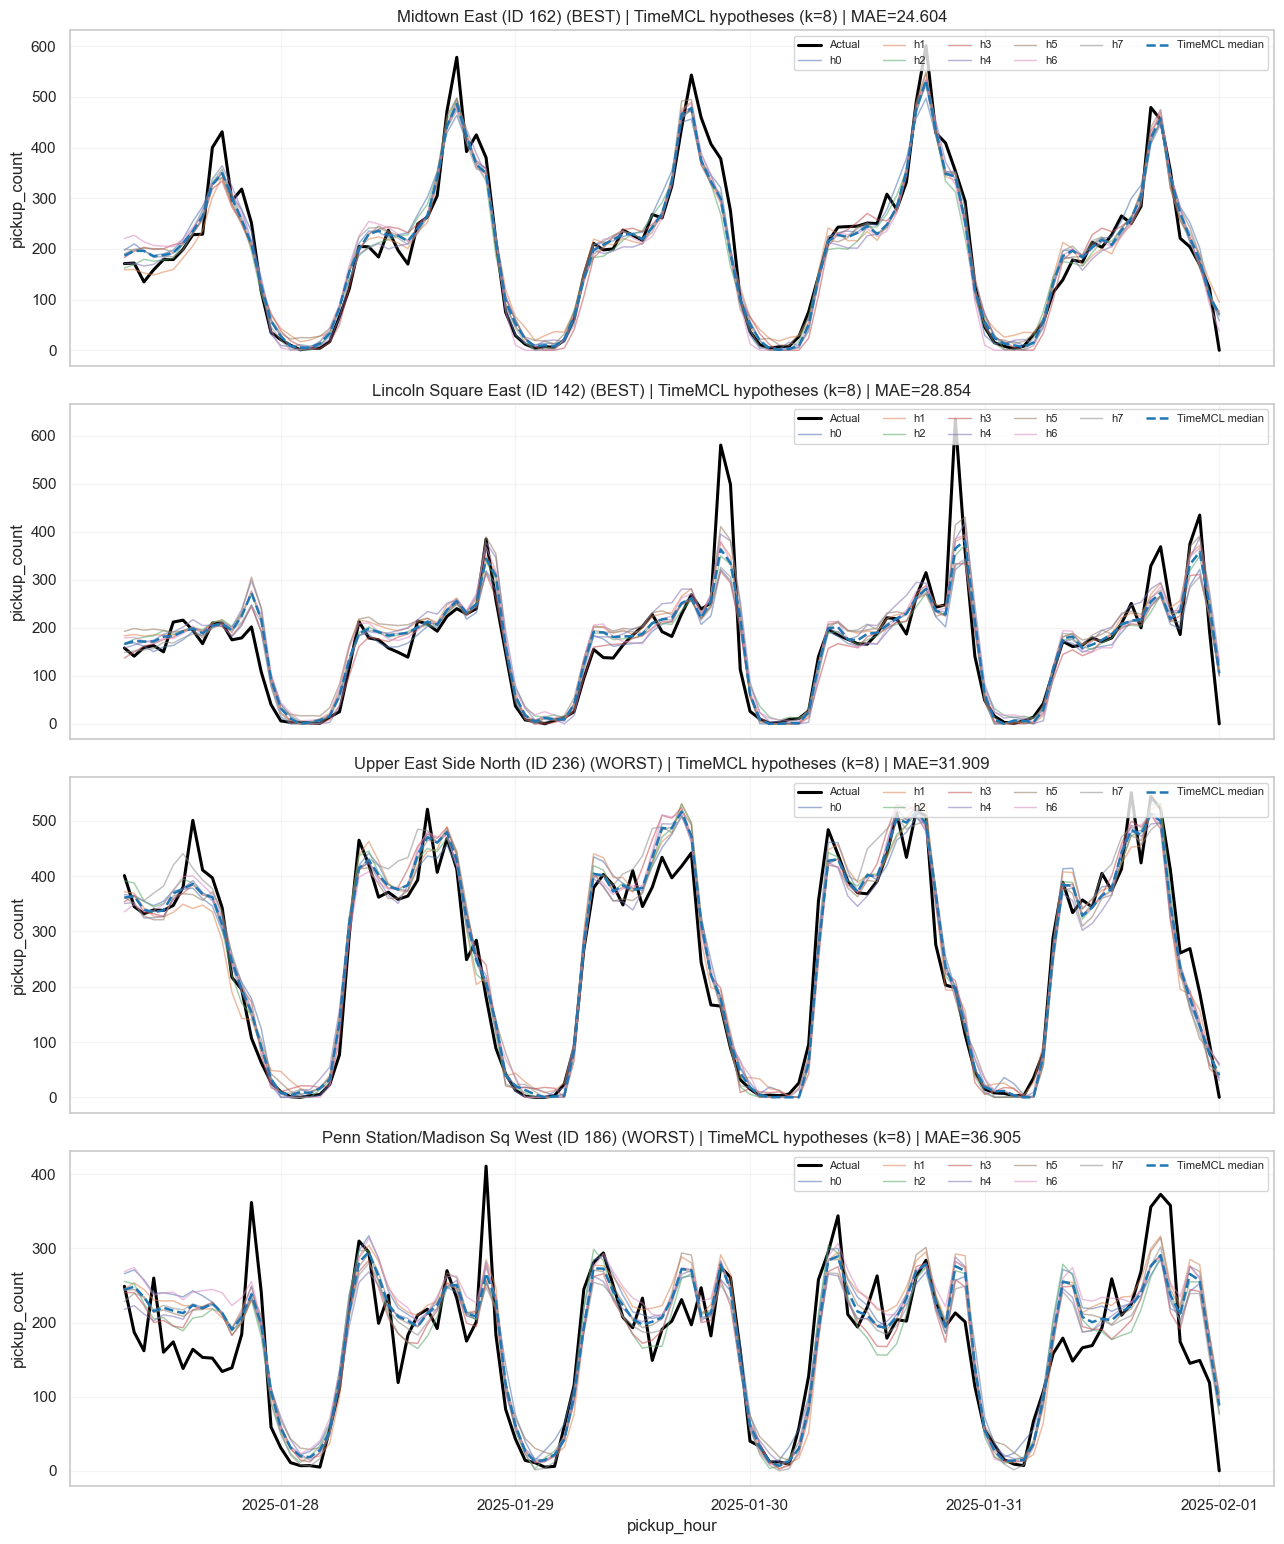

Rendered best/worst zone hypothesis trajectories for k=8.


In [49]:
# ---- Separate graph: best 2 + worst 2 TimeMCL zones (all hypotheses + median) ----
# Requires: tmcl_prob and benchmark_scores from previous cells.

if "tmcl_prob" not in globals():
    raise RuntimeError("tmcl_prob not found. Run the TimeMCL cell first.")
if "benchmark_scores" not in globals():
    raise RuntimeError("benchmark_scores not found. Run the final comparison table cell first.")

if "zone_name_map" not in globals():
    from pathlib import Path
    _lookup_candidates = [Path("data/taxi_zone_lookup.csv"), Path("taxi_zone_lookup.csv")]
    _lookup_path = next((p for p in _lookup_candidates if p.exists()), None)
    if _lookup_path is None:
        raise FileNotFoundError(f"taxi_zone_lookup.csv not found. Tried: {_lookup_candidates}")
    _zl = pd.read_csv(_lookup_path)[["LocationID", "Zone"]].dropna()
    zone_name_map = dict(zip(_zl["LocationID"].astype(int), _zl["Zone"].astype(str)))

def zone_label(zid: int) -> str:
    return f"{zone_name_map.get(int(zid), 'Unknown Zone')} (ID {int(zid)})"

k_hyps = int(tmcl_prob["hypothesis"].nunique())

# Rank zones by TimeMCL MAE (lower is better)
zone_scores = benchmark_scores[
    (benchmark_scores["model"] == "TimeMCL")
    & (benchmark_scores["zone"].astype(str).str.isnumeric())
].copy()
zone_scores["zone"] = zone_scores["zone"].astype(int)
zone_scores = zone_scores.sort_values("MAE").reset_index(drop=True)

if len(zone_scores) < 4:
    selected_zones = zone_scores["zone"].tolist()
else:
    best2 = zone_scores.head(2)["zone"].tolist()
    worst2 = zone_scores.tail(2)["zone"].tolist()
    selected_zones = best2 + worst2

selected_labels = [zone_label(z) for z in selected_zones]
print("Selected TimeMCL zones (best2 + worst2 by MAE):", selected_labels)

fig, axes = plt.subplots(len(selected_zones), 1, figsize=(13, 3.9 * len(selected_zones)), sharex=True)
if len(selected_zones) == 1:
    axes = [axes]

for ax, zone in zip(axes, selected_zones):
    zp = tmcl_prob[tmcl_prob["PULocationID"] == zone].copy()
    if zp.empty:
        ax.set_title(f"{zone_label(zone)}: no TimeMCL hypothesis rows")
        continue

    truth = zp.drop_duplicates("pickup_hour").sort_values("pickup_hour")[["pickup_hour", "y_true"]]
    ax.plot(truth["pickup_hour"], truth["y_true"], color="black", linewidth=2.2, label="Actual")

    hyp_ids = sorted(zp["hypothesis"].unique())
    for h in hyp_ids:
        zh = zp[zp["hypothesis"] == h].sort_values("pickup_hour")
        ax.plot(zh["pickup_hour"], zh["y_pred_h"], linewidth=1.05, alpha=0.55, label=f"h{int(h)}" if h < 10 else None)

    piv = zp.pivot_table(index="pickup_hour", columns="hypothesis", values="y_pred_h").sort_index()
    med = np.median(piv.values, axis=1)
    ax.plot(piv.index, med, linestyle="--", linewidth=1.8, color="tab:blue", label="TimeMCL median")

    zone_mae = zone_scores.loc[zone_scores["zone"] == zone, "MAE"].iloc[0] if zone in zone_scores["zone"].values else np.nan
    zone_tag = "BEST" if zone in zone_scores.head(2)["zone"].tolist() else ("WORST" if zone in zone_scores.tail(2)["zone"].tolist() else "")
    ax.set_title(f"{zone_label(zone)} ({zone_tag}) | TimeMCL hypotheses (k={k_hyps}) | MAE={zone_mae:.3f}")
    ax.set_ylabel("pickup_count")
    ax.grid(alpha=0.2)

    if k_hyps <= 10:
        ax.legend(ncol=min(6, k_hyps + 2), fontsize=8, loc="upper right")
    else:
        ax.legend(["Actual", "TimeMCL median"], fontsize=8, loc="upper right")

axes[-1].set_xlabel("pickup_hour")
plt.tight_layout()
plt.show()

print(f"Rendered best/worst zone hypothesis trajectories for k={k_hyps}.")


## 11. Activity log (advanced benchmark extension)

**Prompt captured:**
- "Inspect my notebook... compare classical (ARIMA/Prophet) vs ML (XGBoost/TimeMCL); evaluate MAE/MAPE; set up TimeMCL and test on this dataset."
- "Now, I want to do the train on `data/yellow_tripdata_2024-01.parquet` and test on `data/yellow_tripdata_2025-01.parquet` for ALL models being tested. Go ahead and implement this, for TimeMCL go back to a full training on ALL training data."

**Implementation steps completed:**
1. Audited existing notebook assets (`model_df`, chronological split, lag features, existing XGBoost outputs).
2. Added a shared benchmark protocol and a unified evaluator for MAE/MAPE.
3. Implemented ARIMA and Prophet for top-K busiest zones (train-only zone selection).
4. Reused (or retrained if needed) pooled XGBoost and converted outputs to the unified prediction schema.
5. Added a TimeMCL-style multi-hypothesis PyTorch model with annealed-WTA training behavior inspired by paper/repo usage.
6. Produced consolidated benchmark tables and representative zone forecast plots.
7. Switched benchmark setup to **cross-year split** (`Jan 2024 -> train`, `Jan 2025 -> test`) by rebuilding the full dense zone-hour panel from both parquet files.
8. Recomputed all shared features (calendar, lags, train-only zone mean, log lag) on the new cross-year panel and routed all benchmark models through this frame.
9. Updated TimeMCL config to use **full training data windows** (`max_train_windows=None`) for final cross-year runs.

**Run metadata:**
- Timestamp: `2026-04-26 15:59:42`
- Split policy (initial): chronological train/val/test inherited from existing notebook pipeline.
- Split policy (current): fixed month holdout (`Jan 2024` train, `Jan 2025` test).
- Metric policy: MAPE denominator `max(|y|, 1)` to handle zero-demand hours.

**References used:**
- [TimeMCL paper](https://arxiv.org/pdf/2506.05515)
- [timeMCL GitHub README](https://github.com/Victorletzelter/timeMCL?tab=readme-ov-file)
